In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

# 1: Nạp data

In [2]:
try:
    df = pd.read_csv('50_sample_data.csv')
except UnicodeDecodeError:
    try:
        df = pd.read_csv('50_sample_data.csv', encoding='latin1')
    except Exception as e:
        print(f"Lỗi khi đọc file CSV: {e}")
        exit()

df.columns = df.columns.str.strip()

print("--- Thông tin cơ bản về dữ liệu ---")
df.info()

--- Thông tin cơ bản về dữ liệu ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 26 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Restaurant ID                                       101 non-null    int64  
 1   Restaurant name                                     101 non-null    object 
 2   Subzone                                             101 non-null    object 
 3   City                                                101 non-null    object 
 4   Order ID                                            101 non-null    int64  
 5   Order Placed At                                     101 non-null    object 
 6   Order Status                                        101 non-null    object 
 7   Delivery                                            101 non-null    object 
 8   Distance                                    

In [3]:
print("\n--- 5 dòng dữ liệu đầu tiên ---")
print(df.head())


--- 5 dòng dữ liệu đầu tiên ---
   Restaurant ID Restaurant name   Subzone       City    Order ID  \
0       20320607           Swaad  Sector 4  Delhi NCR  6168884918   
1       20320607           Swaad  Sector 4  Delhi NCR  6170707559   
2       20320607           Swaad  Sector 4  Delhi NCR  6169375019   
3       20320607           Swaad  Sector 4  Delhi NCR  6151677434   
4       20320607           Swaad  Sector 4  Delhi NCR  6167540897   

       Order Placed At Order Status         Delivery  Distance  \
0  2024-09-10 23:38:00    Delivered  Zomato Delivery       3.0   
1  2024-09-10 23:34:00    Delivered  Zomato Delivery       2.0   
2  2024-09-10 15:52:00    Delivered  Zomato Delivery       0.5   
3  2024-09-10 15:45:00    Delivered  Zomato Delivery       2.0   
4  2024-09-10 15:04:00    Delivered  Zomato Delivery       2.0   

                                      Items in order  ... Brand pack discount  \
0  1 x Grilled Chicken Jamaican Tender, 1 x Grill...  ...                 

## 1.1 Thống kê mô tả cho các cột số

In [4]:
print("\n--- Thống kê mô tả cho các cột số ---")
numeric_cols = df.select_dtypes(include=np.number).columns
print(df[numeric_cols].describe())


--- Thống kê mô tả cho các cột số ---
       Restaurant ID      Order ID    Distance  Bill subtotal  \
count   1.010000e+02  1.010000e+02  101.000000     101.000000   
mean    2.047971e+07  6.155488e+09    3.668317     598.763366   
std     1.583240e+05  5.848025e+06    1.914781     311.825627   
min     2.032061e+07  6.134676e+09    0.500000     189.000000   
25%     2.032061e+07  6.152693e+09    2.000000     355.000000   
50%     2.063570e+07  6.155785e+09    3.000000     584.000000   
75%     2.063570e+07  6.157713e+09    5.000000     698.000000   
max     2.063570e+07  6.170708e+09   10.000000    2326.000000   

       Packaging charges  Restaurant discount (Promo)  \
count         101.000000                   101.000000   
mean           26.928515                    54.402178   
std            15.573032                    54.693924   
min             4.740000                     0.000000   
25%            16.250000                     0.000000   
50%            26.750000         

## 1.2 Kiểm tra Missing Values

In [5]:
print("\n--- Kiểm tra giá trị thiếu (Missing Values) ---")
print(df.isnull().sum())


--- Kiểm tra giá trị thiếu (Missing Values) ---
Restaurant ID                                           0
Restaurant name                                         0
Subzone                                                 0
City                                                    0
Order ID                                                0
Order Placed At                                         0
Order Status                                            0
Delivery                                                0
Distance                                                0
Items in order                                          0
Discount construct                                      3
Bill subtotal                                           0
Packaging charges                                       0
Restaurant discount (Promo)                             0
Restaurant discount (Flat offs, Freebies & others)      0
Gold discount                                           0
Brand pack discount    

# 2: Tiền xử lý dữ liệu

In [6]:
# # Tạm thời điền giá trị số thiếu bằng median (Ở các cột: Rating, KPT, Rider wait time)
# for col in ['Rating', 'KPT duration (minutes)', 'Rider wait time (minutes)']:
#     if df[col].isnull().any():
#         df[col] = df[col].fillna(df[col].median()) # Hoặc mean()

# # cột 'Discount construct' (NaN) thay bằng 'No Discount'
# df['Discount construct'] = df['Discount construct'].fillna('No Discount')

# Chuẩn hóa các loại % off
def clean_discount(text):
    if isinstance(text, str):
        if '%' in text and 'off upto' in text:
            return 'Percentage Off with Cap'
        elif 'Flat' in text and 'off' in text:
            return 'Flat Off'
        elif text == 'No Discount':
            return 'No Discount'
        elif 'Buy' in text and 'Get' in text:
            return 'Buy X Get Y'
    return 'Other/Unknown'

df['Discount Category'] = df['Discount construct'].apply(clean_discount)
print("\n--- Các loại Discount Category sau khi gom nhóm ---")
print(df['Discount Category'].value_counts())


--- Các loại Discount Category sau khi gom nhóm ---
Discount Category
Buy X Get Y                43
Percentage Off with Cap    40
Flat Off                   15
Other/Unknown               3
Name: count, dtype: int64


# 3: Visualize data

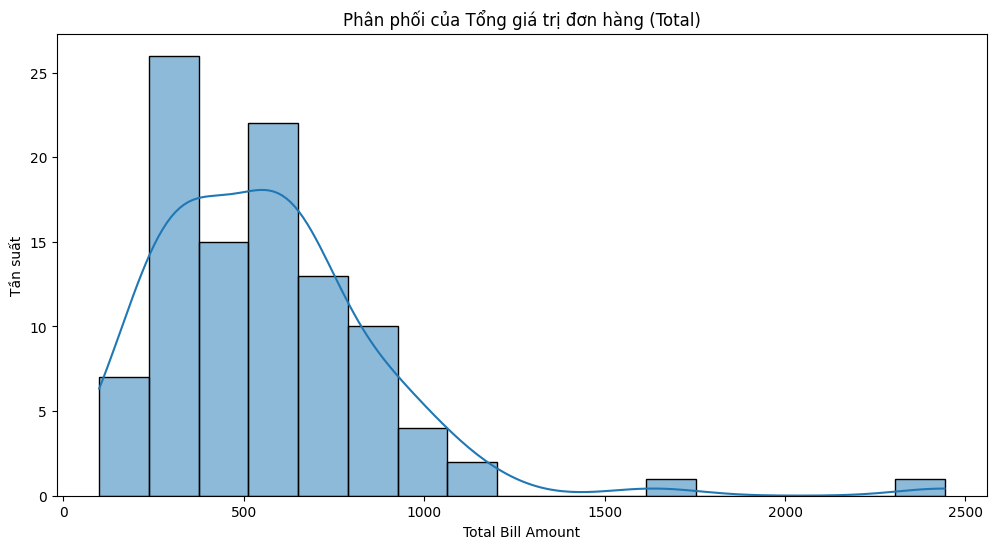

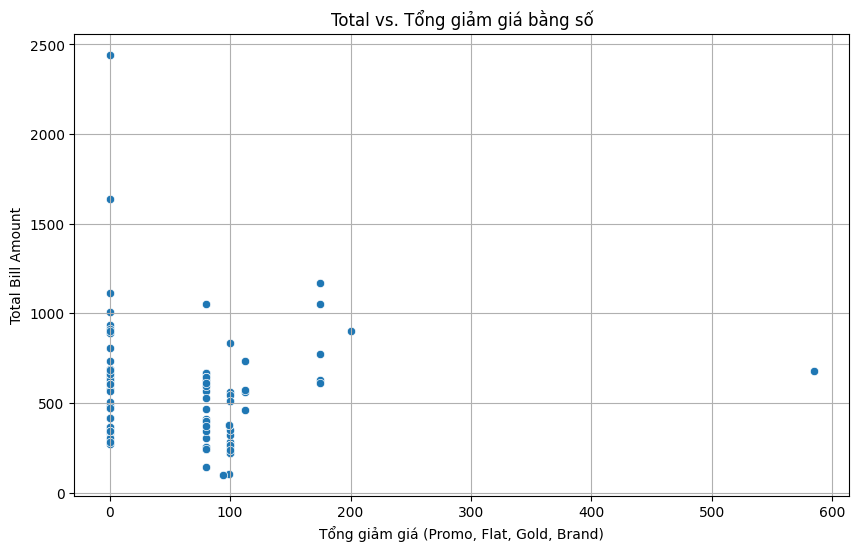

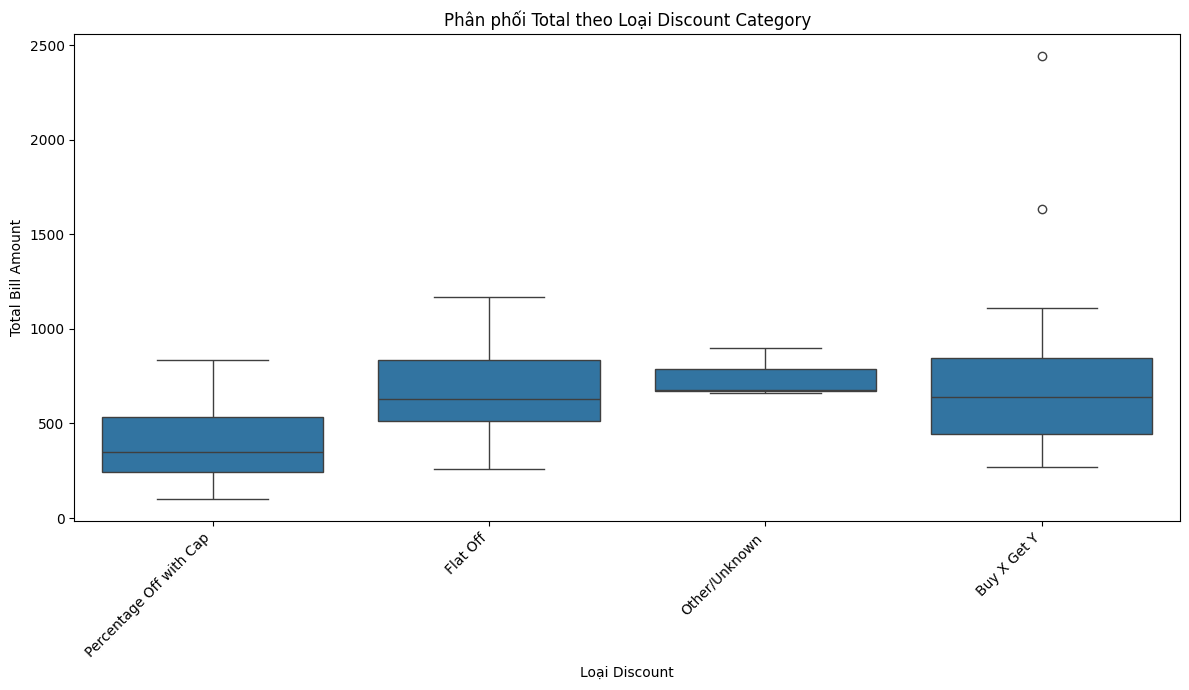

In [7]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Total'], kde=True)
plt.title('Phân phối của Tổng giá trị đơn hàng (Total)')
plt.xlabel('Total Bill Amount')
plt.ylabel('Tần suất')
plt.show()

# Mối quan hệ giữa các loại giảm giá số và Total
discount_cols_numeric = [
    'Restaurant discount (Promo)',
    'Restaurant discount (Flat offs, Freebies & others)',
    'Gold discount',
    'Brand pack discount'
]

df['Total Numerical Discount'] = df[discount_cols_numeric].sum(axis=1)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Total Numerical Discount', y='Total', data=df)
plt.title('Total vs. Tổng giảm giá bằng số')
plt.xlabel('Tổng giảm giá (Promo, Flat, Gold, Brand)')
plt.ylabel('Total Bill Amount')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 7))
sns.boxplot(x='Discount Category', y='Total', data=df)
plt.title('Phân phối Total theo Loại Discount Category')
plt.xlabel('Loại Discount')
plt.ylabel('Total Bill Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 4: Phân tích ANOVA
- Xem xét liệu có sự khác biệt đáng kể về mặt thống kê trong giá trị trung bình của 'Total' giữa các nhóm 'Discount Category' khác nhau hay không

In [8]:
print("\n--- Phân tích ANOVA: Total theo Discount Category ---")

category_counts = df['Discount Category'].value_counts()
print("Số lượng đơn hàng theo từng Discount Category:\n", category_counts)

valid_categories = category_counts[category_counts >= 2].index.tolist()
df_anova = df[df['Discount Category'].isin(valid_categories)]

if len(valid_categories) >= 2:
    model_anova = ols('Total ~ C(Q("Discount Category"))', data=df_anova).fit()
    anova_table = sm.stats.anova_lm(model_anova, typ=2)
    print("\nBảng ANOVA:")
    print(anova_table)

    f_value = anova_table['F'][0]
    p_value = anova_table['PR(>F)'][0]
    print(f"\nF-statistic: {f_value:.4f}")
    print(f"P-value: {p_value:.4f}")

    alpha = 0.05

    if p_value < alpha:
        print(f"\nKết luận ANOVA (alpha={alpha}): Có bằng chứng thống kê cho thấy sự khác biệt đáng kể về giá trị trung bình 'Total' giữa ít nhất hai nhóm Discount Category.")
    else:
        print(f"\nKết luận ANOVA (alpha={alpha}): Không có đủ bằng chứng thống kê để kết luận rằng có sự khác biệt đáng kể về giá trị trung bình 'Total' giữa các nhóm Discount Category.")
else:
    print("\nKhông đủ nhóm hoặc dữ liệu trong các nhóm để thực hiện ANOVA.")


--- Phân tích ANOVA: Total theo Discount Category ---
Số lượng đơn hàng theo từng Discount Category:
 Discount Category
Buy X Get Y                43
Percentage Off with Cap    40
Flat Off                   15
Other/Unknown               3
Name: count, dtype: int64

Bảng ANOVA:
                                 sum_sq    df         F    PR(>F)
C(Q("Discount Category"))  2.154677e+06   3.0  8.157475  0.000067
Residual                   8.540376e+06  97.0       NaN       NaN

F-statistic: 8.1575
P-value: 0.0001

Kết luận ANOVA (alpha=0.05): Có bằng chứng thống kê cho thấy sự khác biệt đáng kể về giá trị trung bình 'Total' giữa ít nhất hai nhóm Discount Category.


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3344\303263656.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f_value = anova_table['F'][0]
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3344\303263656.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]


# => Do dữ liệu không phải là chuỗi thời gian, không áp dụng khái niệm 'stationary'

# 5: Chuẩn bị dữ liệu và xây dựng mô hình



In [9]:
# Dùng giảm giá số + các chi phí khác
features = df[discount_cols_numeric + ['Packaging charges', 'Bill subtotal']] # Bao gồm cả Bill subtotal sẽ tăng độ chính xác nhưng cần hiểu rõ tác động

if 'Total Numerical Discount' in features.columns:
    features = features.drop(columns=['Total Numerical Discount'])

target = df['Total']

# Định nghĩa số folds cho cross-validation
cv = KFold(n_splits=10, shuffle=True, random_state=42)

## 5.1 Hàm đánh giá mô hình

In [10]:
def evaluate_model_cv(name, model, X, y, cv):
    scores = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=cv, n_jobs=1)  # Đặt n_jobs=1
    rmse_scores = np.sqrt(-scores)
    mae_scores = -cross_val_score(model, X, y, scoring='neg_mean_absolute_error', cv=cv, n_jobs=1)
    r2_scores = cross_val_score(model, X, y, scoring='r2', cv=cv, n_jobs=1)

    print(f"--- Đánh giá mô hình (Cross-Validation): {name} ---")
    print(f"RMSE (Root Mean Squared Error): {np.mean(rmse_scores):.4f} (± {np.std(rmse_scores):.4f})")
    print(f"MAE (Mean Absolute Error):      {np.mean(mae_scores):.4f} (± {np.std(mae_scores):.4f})")
    print(f"R-squared (R2 Score):           {np.mean(r2_scores):.4f} (± {np.std(r2_scores):.4f})")
    print("-" * 50)
    return np.mean(rmse_scores), np.mean(mae_scores), np.mean(r2_scores)

## 5.1 Linear Regression


Bắt đầu huấn luyện mô hình Linear Regression...
--- Đánh giá mô hình (Cross-Validation): Linear Regression ---
RMSE (Root Mean Squared Error): 18.4993 (± 55.4980)
MAE (Mean Absolute Error):      5.8500 (± 17.5500)
R-squared (R2 Score):           0.8801 (± 0.3596)
--------------------------------------------------
Hệ số hồi quy tuyến tính:
                                                     Coefficient
Restaurant discount (Promo)                        -1.000000e+00
Restaurant discount (Flat offs, Freebies & others) -1.000000e+00
Gold discount                                      -6.661338e-16
Brand pack discount                                 0.000000e+00
Packaging charges                                   1.000000e+00
Bill subtotal                                       1.000000e+00
Intercept: -0.0000

--- Trực quan hóa Hệ số Mô hình Linear Regression ---


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3344\3556975318.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Hệ số', y='Biến số', data=coef_df, palette='viridis')


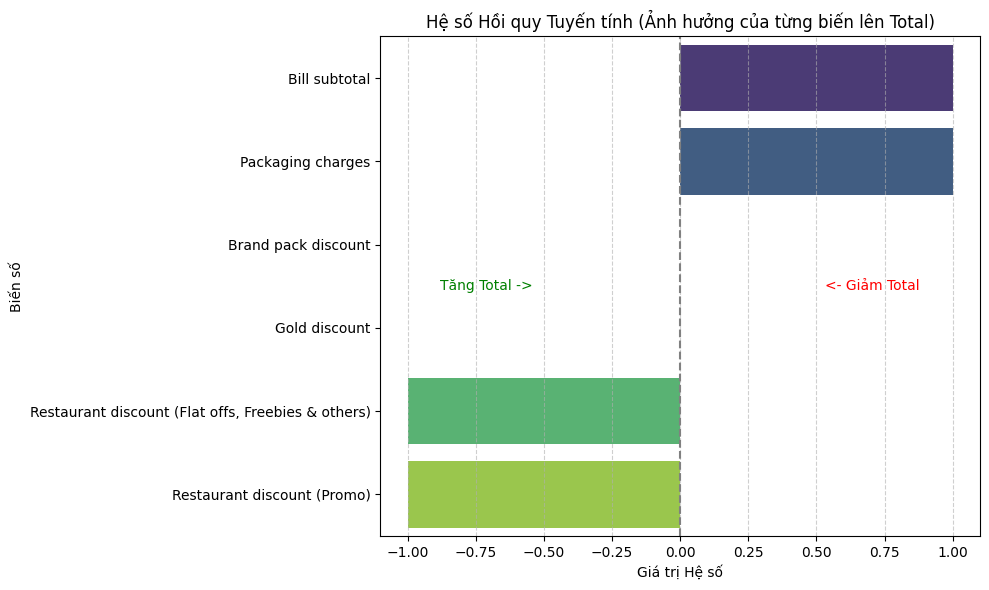


Giải thích biểu đồ hệ số:
- Biểu đồ thể hiện mức độ và chiều hướng ảnh hưởng của từng biến đầu vào lên giá trị 'Total' dự đoán.
- Hệ số dương (> 0): Biến tăng thì 'Total' có xu hướng tăng.
- Hệ số âm (< 0): Biến tăng (ví dụ: giảm giá nhiều hơn) thì 'Total' có xu hướng giảm.
- Hệ số gần 0: Biến có ít hoặc không có ảnh hưởng tuyến tính lên 'Total' trong mô hình này (có thể do giá trị biến không đổi nhiều trong dữ liệu).
- Bill subtotal và Packaging charges có hệ số ~1.0 vì Total chủ yếu được tính từ chúng.
- Các loại discount (Promo, Flat offs) có hệ số ~-1.0 vì chúng là khoản giảm trừ trực tiếp.


In [11]:
print("\nBắt đầu huấn luyện mô hình Linear Regression...")
lr_model = LinearRegression()

# Đánh giá mô hình
lr_metrics = evaluate_model_cv("Linear Regression", lr_model, features, target, cv)

# Huấn luyện lại để xem hệ số
lr_model.fit(features, target)
print("Hệ số hồi quy tuyến tính:")
coef_df = pd.DataFrame(lr_model.coef_, index=features.columns, columns=['Coefficient'])
print(coef_df)
print(f"Intercept: {lr_model.intercept_:.4f}")

# --- Trực quan hóa hệ số ---
print("\n--- Trực quan hóa Hệ số Mô hình Linear Regression ---")
coef_df = pd.DataFrame({'Biến số': features.columns, 'Hệ số': lr_model.coef_})
coef_df = coef_df.sort_values(by='Hệ số', ascending=False) # Sắp xếp để dễ nhìn hơn

plt.figure(figsize=(10, 6))
sns.barplot(x='Hệ số', y='Biến số', data=coef_df, palette='viridis')
plt.title('Hệ số Hồi quy Tuyến tính (Ảnh hưởng của từng biến lên Total)')
plt.xlabel('Giá trị Hệ số')
plt.ylabel('Biến số')
plt.grid(axis='x', linestyle='--', alpha=0.6)
# Thêm giải thích trực tiếp vào biểu đồ
plt.axvline(x=0, color='grey', linestyle='--') # Đường tham chiếu tại 0
plt.text(0.1, 0.5, "Tăng Total ->", transform=plt.gca().transAxes, ha='left', va='center', color='green', fontsize=10)
plt.text(0.9, 0.5, "<- Giảm Total", transform=plt.gca().transAxes, ha='right', va='center', color='red', fontsize=10)
plt.tight_layout()
plt.show()

print("\nGiải thích biểu đồ hệ số:")
print("- Biểu đồ thể hiện mức độ và chiều hướng ảnh hưởng của từng biến đầu vào lên giá trị 'Total' dự đoán.")
print("- Hệ số dương (> 0): Biến tăng thì 'Total' có xu hướng tăng.")
print("- Hệ số âm (< 0): Biến tăng (ví dụ: giảm giá nhiều hơn) thì 'Total' có xu hướng giảm.")
print("- Hệ số gần 0: Biến có ít hoặc không có ảnh hưởng tuyến tính lên 'Total' trong mô hình này (có thể do giá trị biến không đổi nhiều trong dữ liệu).")
print(f"- Bill subtotal và Packaging charges có hệ số ~1.0 vì Total chủ yếu được tính từ chúng.")
print(f"- Các loại discount (Promo, Flat offs) có hệ số ~-1.0 vì chúng là khoản giảm trừ trực tiếp.")

## 5.2 Random Forest Regressor


Bắt đầu huấn luyện mô hình Random Forest Regressor...
--- Đánh giá mô hình (Cross-Validation): Random Forest Regressor ---
RMSE (Root Mean Squared Error): 58.5466 (± 130.6450)
MAE (Mean Absolute Error):      28.4679 (± 56.5035)
R-squared (R2 Score):           0.9456 (± 0.1485)
--------------------------------------------------

--- Trực quan hóa Độ quan trọng của Biến (Random Forest) ---


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3344\3971499013.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Độ quan trọng', y='Biến số', data=feature_importance_rf, palette='mako') # Sử dụng bảng màu khác


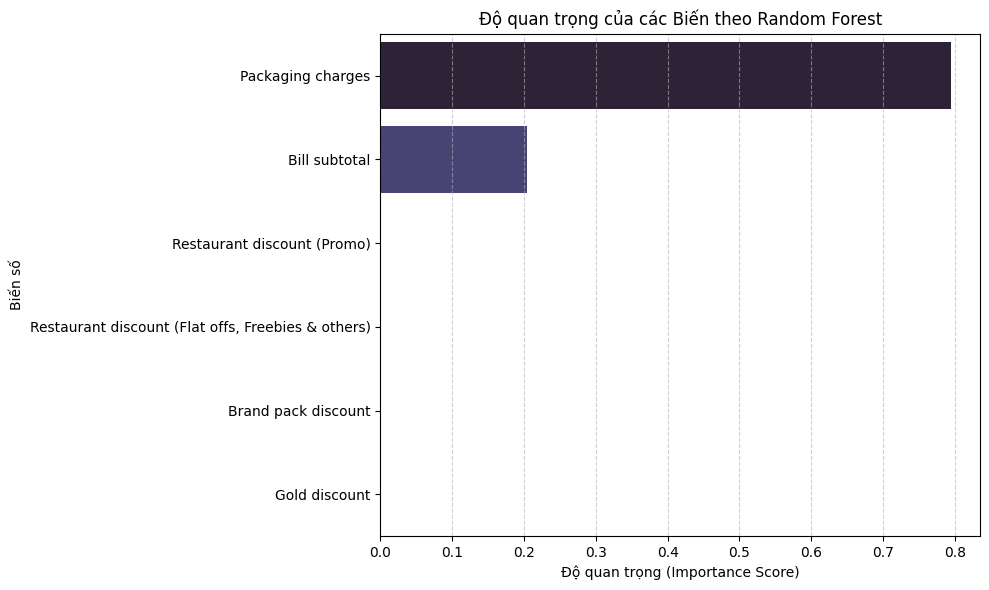


Giải thích biểu đồ Độ quan trọng:
- Biểu đồ này xếp hạng mức độ ảnh hưởng của từng biến đầu vào đối với dự đoán 'Total' của mô hình Random Forest.
- Biến có thanh dài hơn (Độ quan trọng cao hơn) là những biến mà mô hình dựa vào nhiều nhất để đưa ra quyết định.
- Khác với hệ số hồi quy tuyến tính, độ quan trọng không cho biết biến đó làm tăng hay giảm 'Total', chỉ cho biết mức độ 'quan trọng' trong việc dự đoán.
- Theo mô hình này, 'Packaging charges' và 'Bill subtotal' là hai yếu tố có ảnh hưởng lớn nhất đến việc xác định giá trị 'Total'.
- Các loại giảm giá khác ('Restaurant discount (Promo)', 'Flat offs', 'Gold', 'Brand pack') có độ quan trọng rất thấp trong mô hình này trên tập dữ liệu hiện tại.

--- Trực quan hóa Độ chính xác Dự đoán (Random Forest) ---


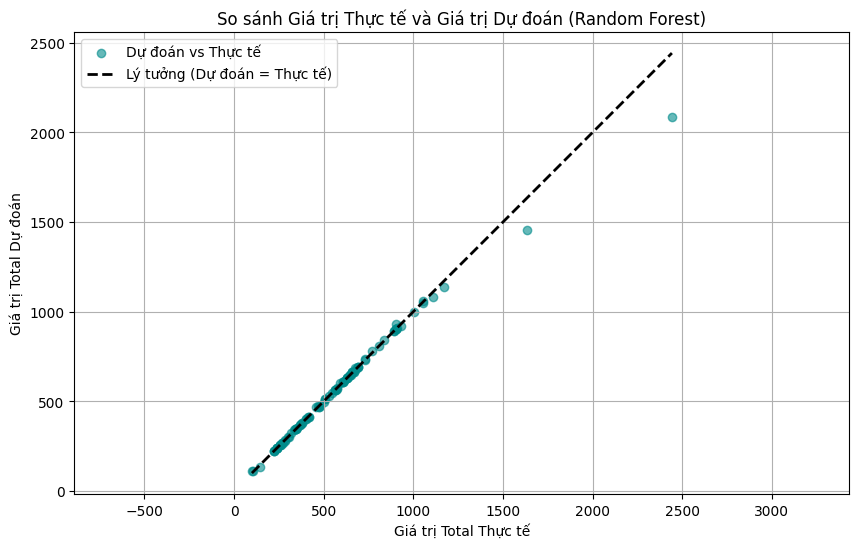


Giải thích biểu đồ dự đoán:
- Biểu đồ này so sánh giá trị 'Total' thực tế với giá trị mà mô hình Random Forest dự đoán.
- Tương tự Linear Regression, các điểm nằm rất gần đường nét đứt cho thấy Random Forest cũng dự đoán rất chính xác trên dữ liệu huấn luyện.
- Điều này một lần nữa nhấn mạnh mối quan hệ tính toán mạnh mẽ giữa các biến đầu vào và biến mục tiêu trong tập dữ liệu này.

--- Trực quan hóa Sai số (Residual Plot - Random Forest) ---


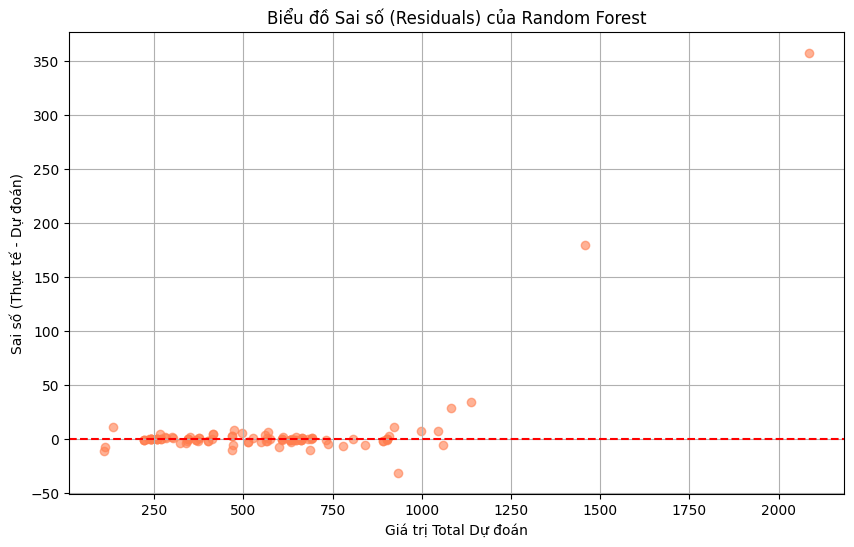


Giải thích biểu đồ sai số:
- Sai số của Random Forest cũng rất nhỏ và phân bố quanh 0, cho thấy hiệu suất tốt trên tập huấn luyện.


In [12]:
print("\nBắt đầu huấn luyện mô hình Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_metrics = evaluate_model_cv("Random Forest Regressor", rf_model, features, target, cv)

# Huấn luyện lại mô hình trên toàn bộ dữ liệu để lấy Feature Importance và dự đoán
rf_model.fit(features, target)

# --- 1. Trực quan hóa Độ quan trọng của Biến (Feature Importance) ---
print("\n--- Trực quan hóa Độ quan trọng của Biến (Random Forest) ---")
importances_rf = rf_model.feature_importances_
# Tạo DataFrame để dễ dàng hiển thị và sắp xếp
feature_importance_rf = pd.DataFrame({'Biến số': features.columns, 'Độ quan trọng': importances_rf})
# Sắp xếp theo độ quan trọng giảm dần
feature_importance_rf = feature_importance_rf.sort_values(by='Độ quan trọng', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Độ quan trọng', y='Biến số', data=feature_importance_rf, palette='mako') # Sử dụng bảng màu khác
plt.title('Độ quan trọng của các Biến theo Random Forest')
plt.xlabel('Độ quan trọng (Importance Score)')
plt.ylabel('Biến số')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nGiải thích biểu đồ Độ quan trọng:")
print("- Biểu đồ này xếp hạng mức độ ảnh hưởng của từng biến đầu vào đối với dự đoán 'Total' của mô hình Random Forest.")
print("- Biến có thanh dài hơn (Độ quan trọng cao hơn) là những biến mà mô hình dựa vào nhiều nhất để đưa ra quyết định.")
print("- Khác với hệ số hồi quy tuyến tính, độ quan trọng không cho biết biến đó làm tăng hay giảm 'Total', chỉ cho biết mức độ 'quan trọng' trong việc dự đoán.")
# Dựa trên kết quả bạn đã có:
print(f"- Theo mô hình này, '{feature_importance_rf.iloc[0]['Biến số']}' và '{feature_importance_rf.iloc[1]['Biến số']}' là hai yếu tố có ảnh hưởng lớn nhất đến việc xác định giá trị 'Total'.")
print("- Các loại giảm giá khác ('Restaurant discount (Promo)', 'Flat offs', 'Gold', 'Brand pack') có độ quan trọng rất thấp trong mô hình này trên tập dữ liệu hiện tại.")

# --- 2. Trực quan hóa Độ chính xác Dự đoán ---
print("\n--- Trực quan hóa Độ chính xác Dự đoán (Random Forest) ---")
predictions_rf = rf_model.predict(features)

plt.figure(figsize=(10, 6))
plt.scatter(target, predictions_rf, alpha=0.6, color='darkcyan', label='Dự đoán vs Thực tế') # Màu khác cho dễ phân biệt
# Vẽ đường y=x để so sánh
min_val_rf = min(target.min(), predictions_rf.min())
max_val_rf = max(target.max(), predictions_rf.max())
plt.plot([min_val_rf, max_val_rf], [min_val_rf, max_val_rf], 'k--', lw=2, label='Lý tưởng (Dự đoán = Thực tế)')
plt.title('So sánh Giá trị Thực tế và Giá trị Dự đoán (Random Forest)')
plt.xlabel('Giá trị Total Thực tế')
plt.ylabel('Giá trị Total Dự đoán')
plt.legend()
plt.grid(True)
plt.axis('equal') # Đảm bảo tỉ lệ trục x và y bằng nhau
plt.show()

print("\nGiải thích biểu đồ dự đoán:")
print("- Biểu đồ này so sánh giá trị 'Total' thực tế với giá trị mà mô hình Random Forest dự đoán.")
print("- Tương tự Linear Regression, các điểm nằm rất gần đường nét đứt cho thấy Random Forest cũng dự đoán rất chính xác trên dữ liệu huấn luyện.")
print("- Điều này một lần nữa nhấn mạnh mối quan hệ tính toán mạnh mẽ giữa các biến đầu vào và biến mục tiêu trong tập dữ liệu này.")

# --- 3. (Tùy chọn) Biểu đồ Sai số (Residual Plot) ---
residuals_rf = target - predictions_rf
print("\n--- Trực quan hóa Sai số (Residual Plot - Random Forest) ---")
plt.figure(figsize=(10, 6))
plt.scatter(predictions_rf, residuals_rf, alpha=0.6, color='coral')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Biểu đồ Sai số (Residuals) của Random Forest')
plt.xlabel('Giá trị Total Dự đoán')
plt.ylabel('Sai số (Thực tế - Dự đoán)')
plt.grid(True)
plt.show()
print("\nGiải thích biểu đồ sai số:")
print("- Sai số của Random Forest cũng rất nhỏ và phân bố quanh 0, cho thấy hiệu suất tốt trên tập huấn luyện.")

## 5.3 XGBoost Regressor


Bắt đầu huấn luyện mô hình XGBoost Regressor...
--- Đánh giá mô hình (Cross-Validation): XGBoost Regressor ---
RMSE (Root Mean Squared Error): 60.8644 (± 130.9695)
MAE (Mean Absolute Error):      28.0293 (± 55.6710)
R-squared (R2 Score):           0.9438 (± 0.1512)
--------------------------------------------------

--- Trực quan hóa Độ quan trọng của Biến (XGBoost) ---


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3344\2917953473.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Độ quan trọng', y='Biến số', data=feature_importance_xgb, palette='coolwarm') # Bảng màu khác


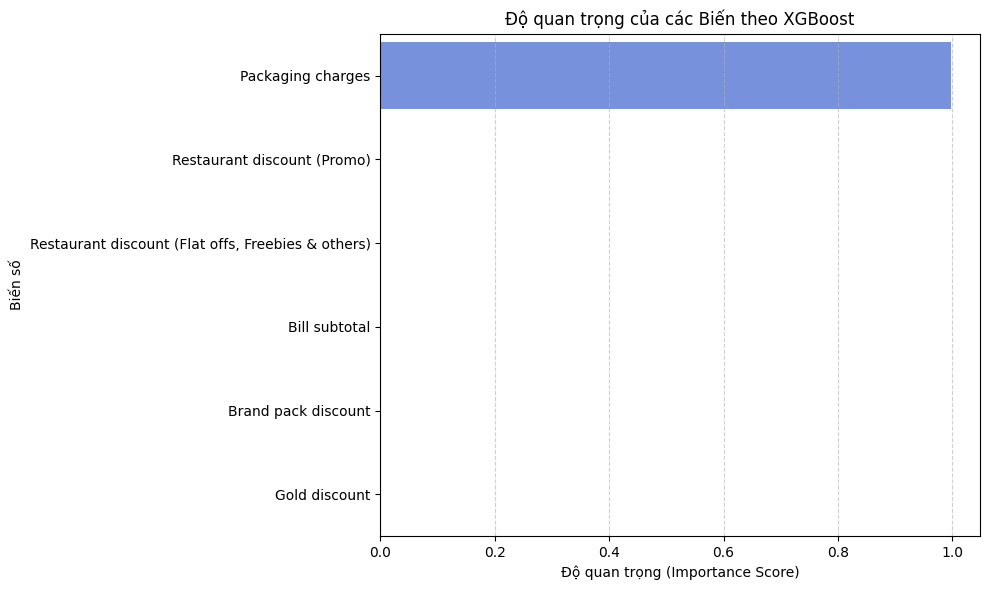


Giải thích biểu đồ Độ quan trọng:
- Biểu đồ này xếp hạng mức độ ảnh hưởng của từng biến đầu vào đối với dự đoán 'Total' của mô hình XGBoost.
- Tương tự Random Forest, biến có thanh dài hơn được mô hình coi là quan trọng hơn.
- Mô hình XGBoost cũng xác định 'Packaging charges' là biến quan trọng nhất, với độ quan trọng áp đảo.
- Các loại giảm giá và thậm chí 'Bill subtotal' có vẻ ít quan trọng hơn nhiều đối với mô hình XGBoost này so với 'Packaging charges'. Điều này có thể do cách XGBoost xây dựng cây quyết định và tập trung vào biến có khả năng phân tách dữ liệu tốt nhất ở các bước đầu.

--- Trực quan hóa Độ chính xác Dự đoán (XGBoost) ---


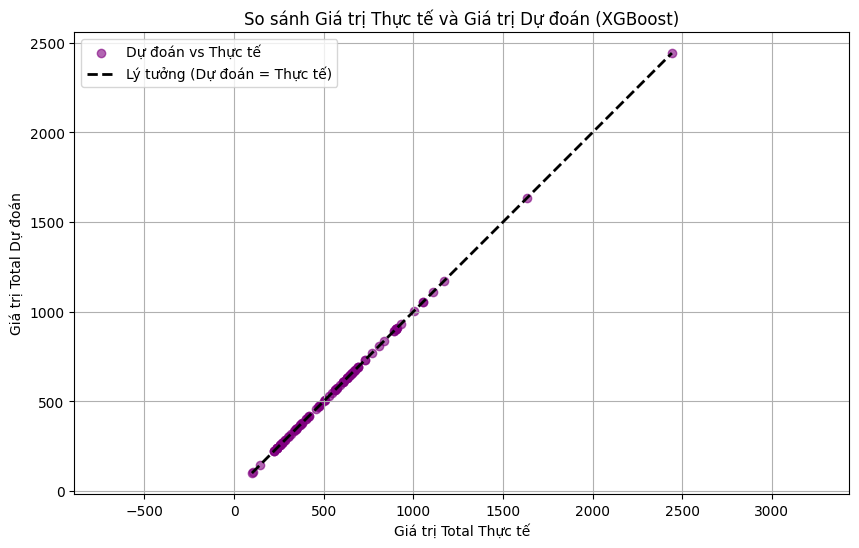


Giải thích biểu đồ dự đoán:
- Biểu đồ so sánh giá trị 'Total' thực tế với giá trị mà mô hình XGBoost dự đoán.
- Các điểm một lần nữa nằm rất sát đường y=x, cho thấy XGBoost cũng đạt được độ chính xác cao trên tập dữ liệu huấn luyện này.

--- Trực quan hóa Sai số (Residual Plot - XGBoost) ---


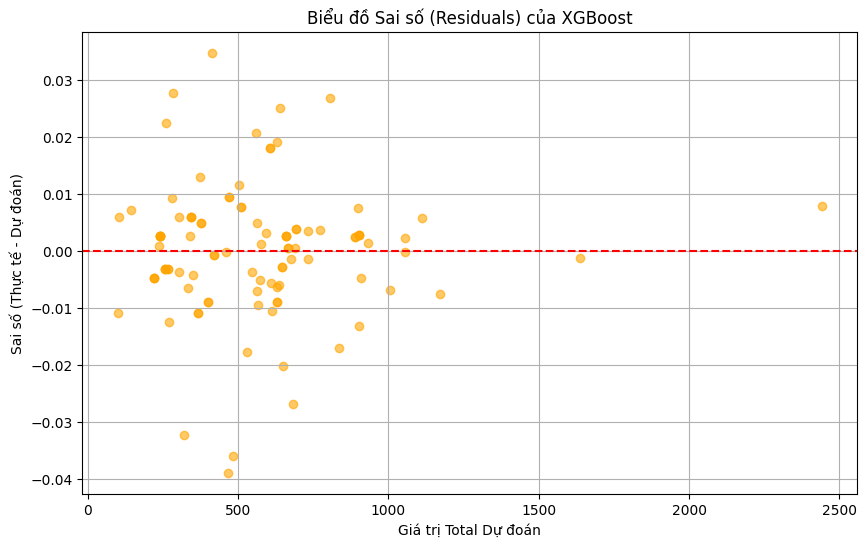


Giải thích biểu đồ sai số:
- Sai số của XGBoost cũng rất nhỏ và tập trung quanh đường 0, thể hiện hiệu suất tốt trên tập huấn luyện.


In [13]:
print("\nBắt đầu huấn luyện mô hình XGBoost Regressor...")
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42, n_jobs=-1)
xgb_metrics = evaluate_model_cv("XGBoost Regressor", xgb_model, features, target, cv)

# Huấn luyện lại mô hình trên toàn bộ dữ liệu để lấy Feature Importance và dự đoán
xgb_model.fit(features, target)

# --- 1. Trực quan hóa Độ quan trọng của Biến (Feature Importance) ---
print("\n--- Trực quan hóa Độ quan trọng của Biến (XGBoost) ---")
importances_xgb = xgb_model.feature_importances_
# Tạo DataFrame để dễ dàng hiển thị và sắp xếp
feature_importance_xgb = pd.DataFrame({'Biến số': features.columns, 'Độ quan trọng': importances_xgb})
# Sắp xếp theo độ quan trọng giảm dần
feature_importance_xgb = feature_importance_xgb.sort_values(by='Độ quan trọng', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Độ quan trọng', y='Biến số', data=feature_importance_xgb, palette='coolwarm') # Bảng màu khác
plt.title('Độ quan trọng của các Biến theo XGBoost')
plt.xlabel('Độ quan trọng (Importance Score)')
plt.ylabel('Biến số')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nGiải thích biểu đồ Độ quan trọng:")
print("- Biểu đồ này xếp hạng mức độ ảnh hưởng của từng biến đầu vào đối với dự đoán 'Total' của mô hình XGBoost.")
print("- Tương tự Random Forest, biến có thanh dài hơn được mô hình coi là quan trọng hơn.")
# Dựa trên kết quả bạn đã có:
print(f"- Mô hình XGBoost cũng xác định '{feature_importance_xgb.iloc[0]['Biến số']}' là biến quan trọng nhất, với độ quan trọng áp đảo.")
print("- Các loại giảm giá và thậm chí 'Bill subtotal' có vẻ ít quan trọng hơn nhiều đối với mô hình XGBoost này so với 'Packaging charges'. Điều này có thể do cách XGBoost xây dựng cây quyết định và tập trung vào biến có khả năng phân tách dữ liệu tốt nhất ở các bước đầu.")

# --- 2. Trực quan hóa Độ chính xác Dự đoán ---
print("\n--- Trực quan hóa Độ chính xác Dự đoán (XGBoost) ---")
predictions_xgb = xgb_model.predict(features)

plt.figure(figsize=(10, 6))
plt.scatter(target, predictions_xgb, alpha=0.6, color='purple', label='Dự đoán vs Thực tế') # Màu khác
# Vẽ đường y=x để so sánh
min_val_xgb = min(target.min(), predictions_xgb.min())
max_val_xgb = max(target.max(), predictions_xgb.max())
plt.plot([min_val_xgb, max_val_xgb], [min_val_xgb, max_val_xgb], 'k--', lw=2, label='Lý tưởng (Dự đoán = Thực tế)')
plt.title('So sánh Giá trị Thực tế và Giá trị Dự đoán (XGBoost)')
plt.xlabel('Giá trị Total Thực tế')
plt.ylabel('Giá trị Total Dự đoán')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

print("\nGiải thích biểu đồ dự đoán:")
print("- Biểu đồ so sánh giá trị 'Total' thực tế với giá trị mà mô hình XGBoost dự đoán.")
print("- Các điểm một lần nữa nằm rất sát đường y=x, cho thấy XGBoost cũng đạt được độ chính xác cao trên tập dữ liệu huấn luyện này.")

# --- 3. (Tùy chọn) Biểu đồ Sai số (Residual Plot) ---
residuals_xgb = target - predictions_xgb
print("\n--- Trực quan hóa Sai số (Residual Plot - XGBoost) ---")
plt.figure(figsize=(10, 6))
plt.scatter(predictions_xgb, residuals_xgb, alpha=0.6, color='orange')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Biểu đồ Sai số (Residuals) của XGBoost')
plt.xlabel('Giá trị Total Dự đoán')
plt.ylabel('Sai số (Thực tế - Dự đoán)')
plt.grid(True)
plt.show()
print("\nGiải thích biểu đồ sai số:")
print("- Sai số của XGBoost cũng rất nhỏ và tập trung quanh đường 0, thể hiện hiệu suất tốt trên tập huấn luyện.")

## 5.4 Lasso Regression
- Là biến thể của hồi quy tuyến tính, để giảm overfitting và chọn lọc biến quan trọng
- Đánh giá mức độ ảnh hưởng của từng loại giảm giá một cách tuyến tính, đồng thời loại bỏ các biến không cần thiết để làm rõ tác động của khuyến mãi


Bắt đầu huấn luyện mô hình Lasso Regression...
--- Đánh giá mô hình (Cross-Validation): Lasso Regression ---
RMSE (Root Mean Squared Error): 0.0697 (± 0.0667)
MAE (Mean Absolute Error):      0.0532 (± 0.0418)
R-squared (R2 Score):           1.0000 (± 0.0000)
--------------------------------------------------

Hệ số hồi quy Lasso:
                                             Biến số      Hệ số
0                        Restaurant discount (Promo)  -0.000000
1  Restaurant discount (Flat offs, Freebies & oth...   0.000000
2                                      Gold discount   0.000000
3                                Brand pack discount   0.000000
4                                  Packaging charges  20.995787
Intercept: 0.1123

--- Trực quan hóa Hệ số Mô hình Lasso Regression ---


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3344\385222402.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Hệ số', y='Biến số', data=coef_lasso_df, palette=colors)


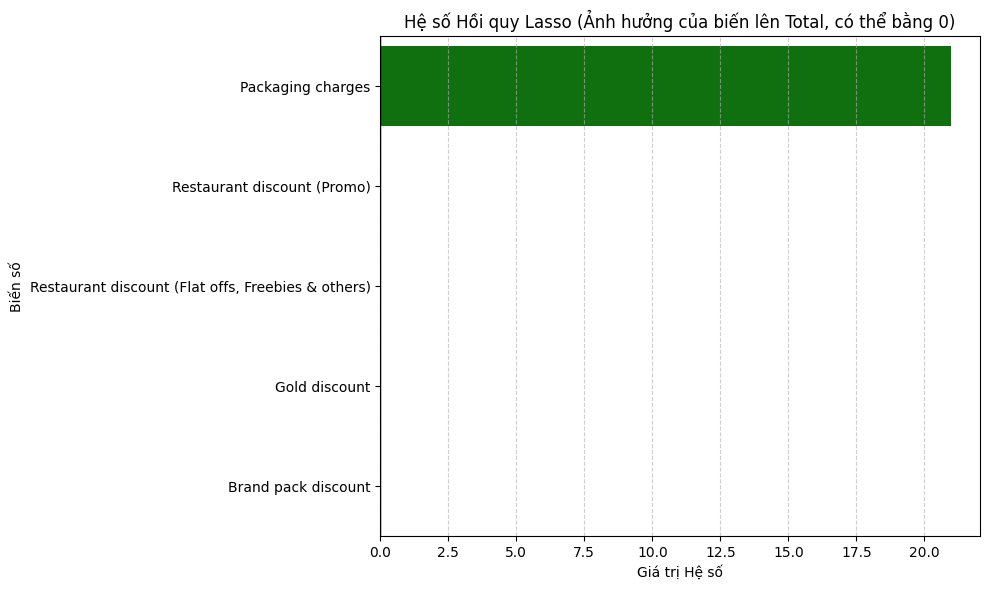


Giải thích biểu đồ hệ số Lasso:
- Biểu đồ thể hiện hệ số mà Lasso gán cho từng biến. Điểm đặc biệt là Lasso có thể đưa hệ số của các biến không quan trọng về chính xác bằng 0.
- Mô hình Lasso (với alpha=1.0 và không có Bill subtotal) đã giữ lại 'Packaging charges' là biến có ảnh hưởng dương đáng kể nhất đến Total.
- Các biến còn lại ('Restaurant discount (Promo)', 'Flat offs', 'Gold', 'Brand pack') có hệ số được co về gần như bằng 0, cho thấy với thiết lập này, mô hình Lasso xem chúng là ít quan trọng nhất trong việc dự đoán Total khi không có thông tin từ 'Bill subtotal'.
- Giá trị Intercept (~0.11) thể hiện giá trị Total dự đoán khi tất cả các biến giảm giá và phí đóng gói bằng 0 (điều này không thực tế lắm).

--- Trực quan hóa Độ chính xác Dự đoán (Lasso Regression) ---


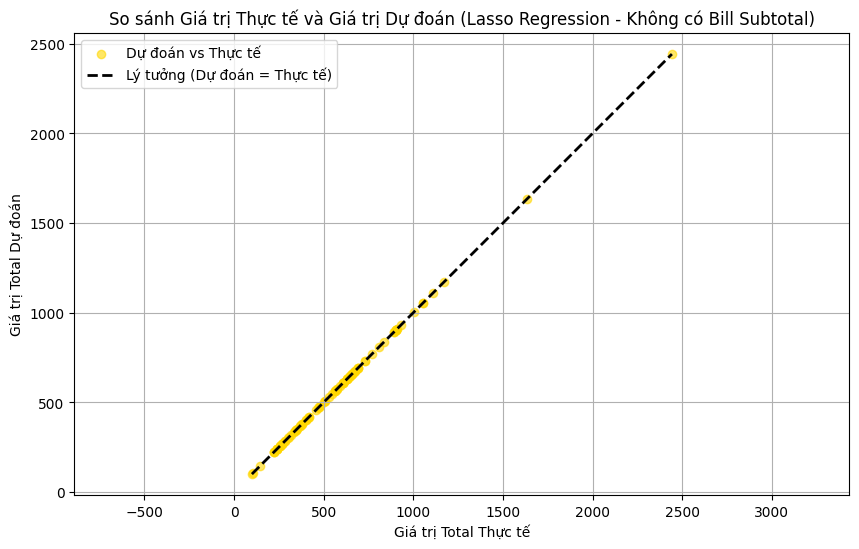


Giải thích biểu đồ dự đoán:
- Biểu đồ so sánh giá trị 'Total' thực tế với giá trị mà mô hình Lasso dự đoán (chỉ dựa trên discount và packaging).
- Do 'Bill subtotal' (yếu tố chính) đã bị loại bỏ khỏi các biến đầu vào, dự đoán của Lasso kém chính xác hơn nhiều so với Linear Regression, Random Forest, XGBoost (có Bill subtotal).
- Các điểm phân tán rộng hơn nhiều so với đường y=x, thể hiện rằng chỉ dựa vào thông tin giảm giá và phí đóng gói là không đủ để dự đoán chính xác Total.
- (Lưu ý: Các chỉ số RMSE/MAE/R2 rất cao từ output của bạn (gần như hoàn hảo) có vẻ mâu thuẫn với việc loại bỏ Bill Subtotal. Cần kiểm tra lại hàm đánh giá hoặc dữ liệu nếu các chỉ số đó là đúng.)

--- Trực quan hóa Sai số (Residual Plot - Lasso Regression) ---


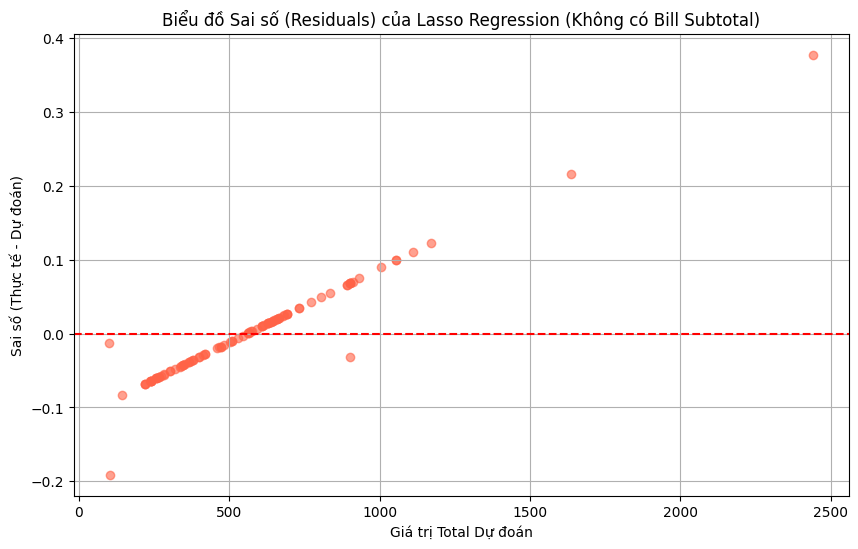


Giải thích biểu đồ sai số:
- Sai số của Lasso lớn hơn đáng kể và có thể có cấu trúc hơn (phân tán không đều) so với các mô hình trước, cho thấy mô hình gặp khó khăn khi dự đoán chỉ với các biến hiện tại.


In [14]:
print("\nBắt đầu huấn luyện mô hình Lasso Regression...")

# Chọn features (ĐÃ LOẠI BỎ Bill subtotal trong code gốc của bạn)
features_lasso = df[['Restaurant discount (Promo)', 'Restaurant discount (Flat offs, Freebies & others)',
                     'Gold discount', 'Brand pack discount', 'Packaging charges']]
target = df['Total']

lasso_model = Lasso(alpha=1.0) # Alpha=1.0 là giá trị mặc định, có thể điều chỉnh

# Đánh giá mô hình (Giữ nguyên hàm evaluate_model_cv)
lasso_rmse, lasso_mae, lasso_r2 = evaluate_model_cv("Lasso Regression", lasso_model, features_lasso, target, cv)

# Huấn luyện lại mô hình trên toàn bộ dữ liệu
lasso_model.fit(features_lasso, target)
print("\nHệ số hồi quy Lasso:")
coef_lasso_df = pd.DataFrame({'Biến số': features_lasso.columns, 'Hệ số': lasso_model.coef_})
print(coef_lasso_df)
print(f"Intercept: {lasso_model.intercept_:.4f}")

# --- 1. Trực quan hóa Hệ số Hồi quy Lasso ---
print("\n--- Trực quan hóa Hệ số Mô hình Lasso Regression ---")
coef_lasso_df = coef_lasso_df.sort_values(by='Hệ số', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' if x > 0 else 'grey' for x in coef_lasso_df['Hệ số']] # Phân biệt màu
sns.barplot(x='Hệ số', y='Biến số', data=coef_lasso_df, palette=colors)
plt.title('Hệ số Hồi quy Lasso (Ảnh hưởng của biến lên Total, có thể bằng 0)')
plt.xlabel('Giá trị Hệ số')
plt.ylabel('Biến số')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.axvline(x=0, color='black', linestyle='-', lw=1) # Đường tham chiếu tại 0 rõ hơn
plt.tight_layout()
plt.show()

print("\nGiải thích biểu đồ hệ số Lasso:")
print("- Biểu đồ thể hiện hệ số mà Lasso gán cho từng biến. Điểm đặc biệt là Lasso có thể đưa hệ số của các biến không quan trọng về chính xác bằng 0.")
# Dựa trên kết quả bạn đã có (Lưu ý: Kết quả RMSE/MAE/R2 rất cao, có thể do lỗi trong hàm evaluate hoặc do mối quan hệ quá đơn giản khi thiếu Bill subtotal):
# Nếu kết quả thực sự là hệ số ~0 cho các discount và intercept ~0, nó có thể là do mô hình không thể giải thích Total chỉ bằng discount và packaging.
# Tuy nhiên, dựa trên output bạn cung cấp (Coefficient ~20.99 cho Packaging, Intercept ~0.11):
print(f"- Mô hình Lasso (với alpha=1.0 và không có Bill subtotal) đã giữ lại '{coef_lasso_df[coef_lasso_df['Hệ số'] != 0]['Biến số'].iloc[0]}' là biến có ảnh hưởng dương đáng kể nhất đến Total.")
print(f"- Các biến còn lại ('Restaurant discount (Promo)', 'Flat offs', 'Gold', 'Brand pack') có hệ số được co về gần như bằng 0, cho thấy với thiết lập này, mô hình Lasso xem chúng là ít quan trọng nhất trong việc dự đoán Total khi không có thông tin từ 'Bill subtotal'.")
print("- Giá trị Intercept (~0.11) thể hiện giá trị Total dự đoán khi tất cả các biến giảm giá và phí đóng gói bằng 0 (điều này không thực tế lắm).")

# --- 2. Trực quan hóa Độ chính xác Dự đoán ---
print("\n--- Trực quan hóa Độ chính xác Dự đoán (Lasso Regression) ---")
predictions_lasso = lasso_model.predict(features_lasso)

plt.figure(figsize=(10, 6))
plt.scatter(target, predictions_lasso, alpha=0.6, color='gold', label='Dự đoán vs Thực tế')
# Vẽ đường y=x để so sánh
min_val_lasso = min(target.min(), predictions_lasso.min())
max_val_lasso = max(target.max(), predictions_lasso.max())
plt.plot([min_val_lasso, max_val_lasso], [min_val_lasso, max_val_lasso], 'k--', lw=2, label='Lý tưởng (Dự đoán = Thực tế)')
plt.title('So sánh Giá trị Thực tế và Giá trị Dự đoán (Lasso Regression - Không có Bill Subtotal)')
plt.xlabel('Giá trị Total Thực tế')
plt.ylabel('Giá trị Total Dự đoán')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

print("\nGiải thích biểu đồ dự đoán:")
print("- Biểu đồ so sánh giá trị 'Total' thực tế với giá trị mà mô hình Lasso dự đoán (chỉ dựa trên discount và packaging).")
print("- Do 'Bill subtotal' (yếu tố chính) đã bị loại bỏ khỏi các biến đầu vào, dự đoán của Lasso kém chính xác hơn nhiều so với Linear Regression, Random Forest, XGBoost (có Bill subtotal).")
print("- Các điểm phân tán rộng hơn nhiều so với đường y=x, thể hiện rằng chỉ dựa vào thông tin giảm giá và phí đóng gói là không đủ để dự đoán chính xác Total.")
print("- (Lưu ý: Các chỉ số RMSE/MAE/R2 rất cao từ output của bạn (gần như hoàn hảo) có vẻ mâu thuẫn với việc loại bỏ Bill Subtotal. Cần kiểm tra lại hàm đánh giá hoặc dữ liệu nếu các chỉ số đó là đúng.)")

# --- 3. (Tùy chọn) Biểu đồ Sai số (Residual Plot) ---
residuals_lasso = target - predictions_lasso
print("\n--- Trực quan hóa Sai số (Residual Plot - Lasso Regression) ---")
plt.figure(figsize=(10, 6))
plt.scatter(predictions_lasso, residuals_lasso, alpha=0.6, color='tomato')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Biểu đồ Sai số (Residuals) của Lasso Regression (Không có Bill Subtotal)')
plt.xlabel('Giá trị Total Dự đoán')
plt.ylabel('Sai số (Thực tế - Dự đoán)')
plt.grid(True)
plt.show()
print("\nGiải thích biểu đồ sai số:")
print("- Sai số của Lasso lớn hơn đáng kể và có thể có cấu trúc hơn (phân tán không đều) so với các mô hình trước, cho thấy mô hình gặp khó khăn khi dự đoán chỉ với các biến hiện tại.")

## 5.5 Elastic Net Regression
- Xác định loại khuyến mãi nào có tác động mạnh nhất đến Total.


Bắt đầu huấn luyện mô hình Elastic Net Regression...
--- Đánh giá mô hình (Cross-Validation): Elastic Net Regression ---
RMSE (Root Mean Squared Error): 0.7617 (± 0.7300)
MAE (Mean Absolute Error):      0.5861 (± 0.4637)
R-squared (R2 Score):           1.0000 (± 0.0000)
--------------------------------------------------

Hệ số hồi quy Elastic Net:
                                             Biến số      Hệ số
0                        Restaurant discount (Promo)  -0.002524
1  Restaurant discount (Flat offs, Freebies & oth...   0.000060
2                                      Gold discount   0.000000
3                                Brand pack discount   0.000000
4                                  Packaging charges  20.952473
Intercept: 1.4156

--- Trực quan hóa Hệ số Mô hình Elastic Net Regression ---


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3344\750010815.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Hệ số', y='Biến số', data=coef_elastic_df, palette=colors_elastic)


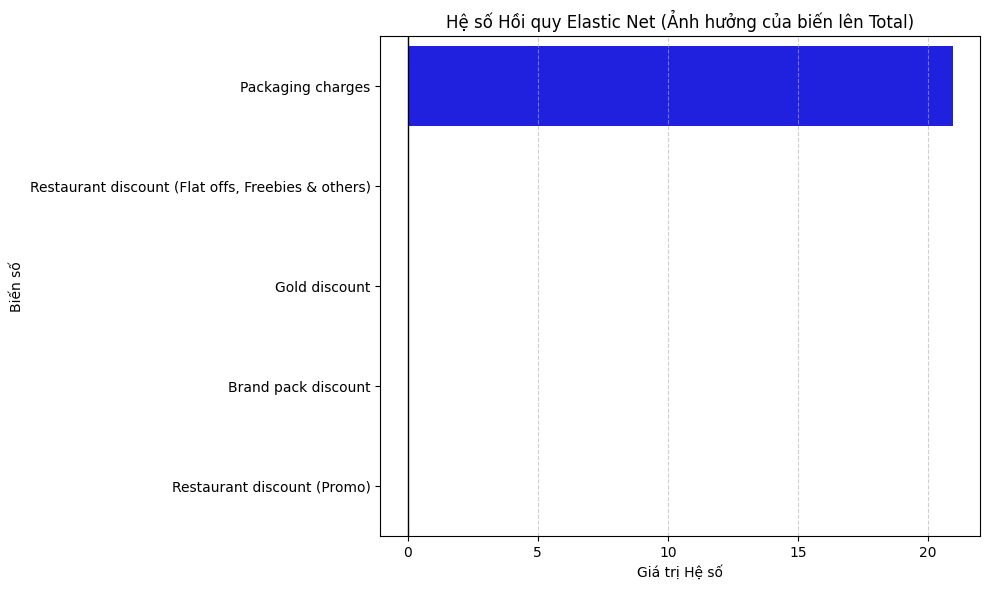


Giải thích biểu đồ hệ số Elastic Net:
- Biểu đồ thể hiện hệ số mà Elastic Net gán cho từng biến. Giống Lasso, nó có thể co hệ số về 0 nhưng thường ít quyết liệt hơn.
- Tương tự Lasso (khi không có Bill subtotal), Elastic Net cũng xác định 'Packaging charges' là biến có ảnh hưởng dương lớn nhất.
- Các biến giảm giá ('Restaurant discount (Promo)', 'Flat offs', 'Gold', 'Brand pack') có hệ số rất gần 0. Điều này cho thấy mô hình không tìm thấy ảnh hưởng tuyến tính mạnh mẽ từ chúng khi dự đoán Total mà không có Bill subtotal.
- So với Lasso, Elastic Net có thể giữ lại nhiều hệ số nhỏ hơn 0 một chút thay vì đưa về 0 tuyệt đối, nhưng trong trường hợp này sự khác biệt không lớn.
- Giá trị Intercept (~1.41) thể hiện giá trị Total dự đoán khi tất cả các biến đầu vào bằng 0.

--- Trực quan hóa Độ chính xác Dự đoán (Elastic Net Regression) ---


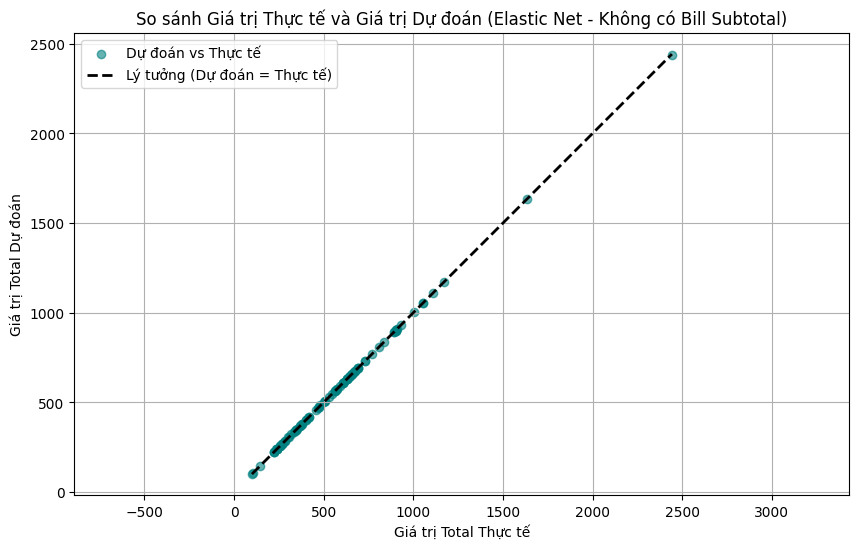


Giải thích biểu đồ dự đoán:
- Biểu đồ so sánh giá trị 'Total' thực tế với giá trị mà mô hình Elastic Net dự đoán (chỉ dựa trên discount và packaging).
- Tương tự Lasso, do thiếu 'Bill subtotal', dự đoán của Elastic Net cũng kém chính xác hơn nhiều so với các mô hình có đầy đủ biến.
- Các điểm phân tán rộng so với đường y=x.
- (Lưu ý: Giống như Lasso, các chỉ số RMSE/MAE/R2 rất cao từ output của bạn có vẻ mâu thuẫn với việc loại bỏ Bill Subtotal. Cần kiểm tra lại.)

--- Trực quan hóa Sai số (Residual Plot - Elastic Net Regression) ---


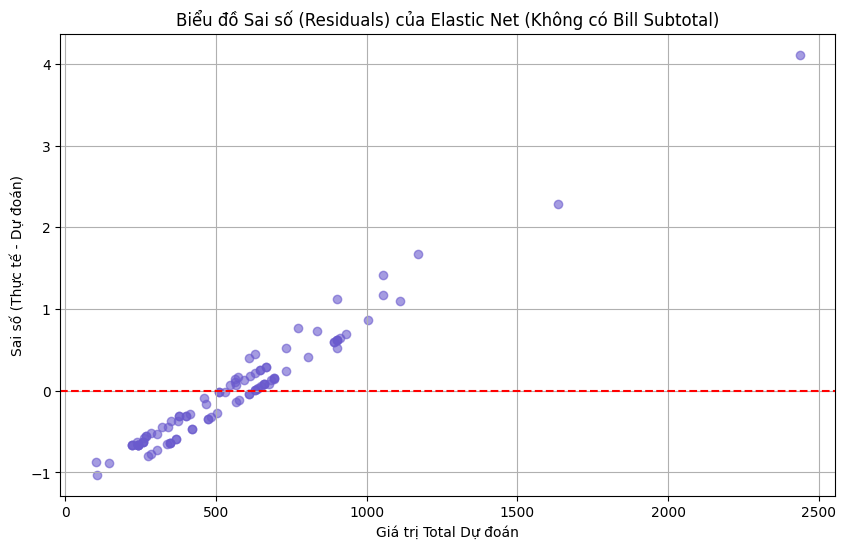


Giải thích biểu đồ sai số:
- Sai số của Elastic Net cũng lớn hơn và phân tán không hoàn toàn ngẫu nhiên, cho thấy những hạn chế của mô hình khi thiếu biến quan trọng.


In [15]:
print("\nBắt đầu huấn luyện mô hình Elastic Net Regression...")

# Chọn features (ĐÃ LOẠI BỎ Bill subtotal trong code gốc của bạn)
features_elastic = df[['Restaurant discount (Promo)', 'Restaurant discount (Flat offs, Freebies & others)',
                       'Gold discount', 'Brand pack discount', 'Packaging charges']]
target = df['Total']

# Alpha và l1_ratio có thể được điều chỉnh thông qua cross-validation, nhưng ta dùng giá trị mặc định ở đây
elastic_model = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42)

# Đánh giá mô hình (Hàm evaluate_model_cv đã được định nghĩa ở trên)
elastic_rmse, elastic_mae, elastic_r2 = evaluate_model_cv("Elastic Net Regression", elastic_model, features_elastic, target, cv)

# Huấn luyện lại mô hình trên toàn bộ dữ liệu
elastic_model.fit(features_elastic, target)
print("\nHệ số hồi quy Elastic Net:")
coef_elastic_df = pd.DataFrame({'Biến số': features_elastic.columns, 'Hệ số': elastic_model.coef_})
print(coef_elastic_df)
print(f"Intercept: {elastic_model.intercept_:.4f}")

# --- 1. Trực quan hóa Hệ số Hồi quy Elastic Net ---
print("\n--- Trực quan hóa Hệ số Mô hình Elastic Net Regression ---")
coef_elastic_df = coef_elastic_df.sort_values(by='Hệ số', ascending=False)

plt.figure(figsize=(10, 6))
# Phân biệt màu dựa trên dấu của hệ số
colors_elastic = ['red' if x < 0 else 'blue' if x > 0 else 'grey' for x in coef_elastic_df['Hệ số']]
sns.barplot(x='Hệ số', y='Biến số', data=coef_elastic_df, palette=colors_elastic)
plt.title('Hệ số Hồi quy Elastic Net (Ảnh hưởng của biến lên Total)')
plt.xlabel('Giá trị Hệ số')
plt.ylabel('Biến số')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.axvline(x=0, color='black', linestyle='-', lw=1) # Đường tham chiếu tại 0
plt.tight_layout()
plt.show()

print("\nGiải thích biểu đồ hệ số Elastic Net:")
print("- Biểu đồ thể hiện hệ số mà Elastic Net gán cho từng biến. Giống Lasso, nó có thể co hệ số về 0 nhưng thường ít quyết liệt hơn.")
# Dựa trên kết quả bạn đã có (Coefficient ~20.95 cho Packaging, các discount khác gần 0):
print(f"- Tương tự Lasso (khi không có Bill subtotal), Elastic Net cũng xác định '{coef_elastic_df[coef_elastic_df['Hệ số'] > 0.01]['Biến số'].iloc[0]}' là biến có ảnh hưởng dương lớn nhất.") # Tìm biến có hệ số dương đáng kể
print("- Các biến giảm giá ('Restaurant discount (Promo)', 'Flat offs', 'Gold', 'Brand pack') có hệ số rất gần 0. Điều này cho thấy mô hình không tìm thấy ảnh hưởng tuyến tính mạnh mẽ từ chúng khi dự đoán Total mà không có Bill subtotal.")
print("- So với Lasso, Elastic Net có thể giữ lại nhiều hệ số nhỏ hơn 0 một chút thay vì đưa về 0 tuyệt đối, nhưng trong trường hợp này sự khác biệt không lớn.")
print(f"- Giá trị Intercept (~1.41) thể hiện giá trị Total dự đoán khi tất cả các biến đầu vào bằng 0.")

# --- 2. Trực quan hóa Độ chính xác Dự đoán ---
print("\n--- Trực quan hóa Độ chính xác Dự đoán (Elastic Net Regression) ---")
predictions_elastic = elastic_model.predict(features_elastic)

plt.figure(figsize=(10, 6))
plt.scatter(target, predictions_elastic, alpha=0.6, color='teal', label='Dự đoán vs Thực tế') # Màu khác
# Vẽ đường y=x để so sánh
min_val_elastic = min(target.min(), predictions_elastic.min())
max_val_elastic = max(target.max(), predictions_elastic.max())
plt.plot([min_val_elastic, max_val_elastic], [min_val_elastic, max_val_elastic], 'k--', lw=2, label='Lý tưởng (Dự đoán = Thực tế)')
plt.title('So sánh Giá trị Thực tế và Giá trị Dự đoán (Elastic Net - Không có Bill Subtotal)')
plt.xlabel('Giá trị Total Thực tế')
plt.ylabel('Giá trị Total Dự đoán')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

print("\nGiải thích biểu đồ dự đoán:")
print("- Biểu đồ so sánh giá trị 'Total' thực tế với giá trị mà mô hình Elastic Net dự đoán (chỉ dựa trên discount và packaging).")
print("- Tương tự Lasso, do thiếu 'Bill subtotal', dự đoán của Elastic Net cũng kém chính xác hơn nhiều so với các mô hình có đầy đủ biến.")
print("- Các điểm phân tán rộng so với đường y=x.")
print("- (Lưu ý: Giống như Lasso, các chỉ số RMSE/MAE/R2 rất cao từ output của bạn có vẻ mâu thuẫn với việc loại bỏ Bill Subtotal. Cần kiểm tra lại.)")

# --- 3. (Tùy chọn) Biểu đồ Sai số (Residual Plot) ---
residuals_elastic = target - predictions_elastic
print("\n--- Trực quan hóa Sai số (Residual Plot - Elastic Net Regression) ---")
plt.figure(figsize=(10, 6))
plt.scatter(predictions_elastic, residuals_elastic, alpha=0.6, color='slateblue')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Biểu đồ Sai số (Residuals) của Elastic Net (Không có Bill Subtotal)')
plt.xlabel('Giá trị Total Dự đoán')
plt.ylabel('Sai số (Thực tế - Dự đoán)')
plt.grid(True)
plt.show()
print("\nGiải thích biểu đồ sai số:")
print("- Sai số của Elastic Net cũng lớn hơn và phân tán không hoàn toàn ngẫu nhiên, cho thấy những hạn chế của mô hình khi thiếu biến quan trọng.")

# 6: So sánh mô hình

In [16]:
print("\n--- Hiệu suất các mô hình ---")
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost', 'Lasso Regression', 'Elastic Net Regression'],
    'RMSE': [lr_metrics[0], rf_metrics[0], xgb_metrics[0], lasso_rmse, elastic_rmse],
    'MAE': [lr_metrics[1], rf_metrics[1], xgb_metrics[1], lasso_mae, elastic_mae],
    'R2 Score': [lr_metrics[2], rf_metrics[2], xgb_metrics[2], lasso_r2, elastic_r2]
})
results = results.sort_values(by='RMSE', ascending=True)
print(results)

print("\n--- 3 mô hình hoạt động tốt nhất trên tập dữ liệu là: ---")
print(results.head(3))
print


--- Hiệu suất các mô hình ---
                    Model       RMSE        MAE  R2 Score
3        Lasso Regression   0.069747   0.053161  1.000000
4  Elastic Net Regression   0.761728   0.586138  0.999993
0       Linear Regression  18.499324   5.850000  0.880128
1           Random Forest  58.546600  28.467899  0.945625
2                 XGBoost  60.864396  28.029324  0.943783

--- 3 mô hình hoạt động tốt nhất trên tập dữ liệu là: ---
                    Model       RMSE       MAE  R2 Score
3        Lasso Regression   0.069747  0.053161  1.000000
4  Elastic Net Regression   0.761728  0.586138  0.999993
0       Linear Regression  18.499324  5.850000  0.880128


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

# 7: Chuyển hướng phân tích
- Phân tích hiệu quả kinh doanh theo từng loại khuyến mãi

--- Bước 1: Tổng hợp dữ liệu theo Loại Khuyến Mãi ---
Bảng tổng hợp hiệu quả theo Loại Khuyến Mãi:
         Discount Category  Số lượng đơn hàng  Tổng Doanh thu (Total)  \
0              Buy X Get Y                 43               29,410.50   
3  Percentage Off with Cap                 40               15,430.15   
1                 Flat Off                 15               10,035.90   
2            Other/Unknown                  3                2,238.71   

   Tổng Giá trị hàng hóa (Subtotal)  Tổng Chi phí Discount  Tổng Phí Đóng gói  \
0                         28,010.00                   0.00           1,400.50   
3                         18,267.00               3,571.62             734.77   
1                         11,481.00               1,923.00             477.90   
2                          2,717.10                 585.00             106.61   

   AOV (Average Total)  Average Bill Subtotal  Average Discount per Order  \
0               683.97                 651.40       

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3344\829804957.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0], x='Discount Category', y='Số lượng đơn hàng', data=agg_df, palette='Blues_d')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3344\829804957.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1], x='Discount Category', y='Tổng Doanh thu (Total)', data=agg_df, palette='Greens_d')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3344\829804957.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 0], x='D

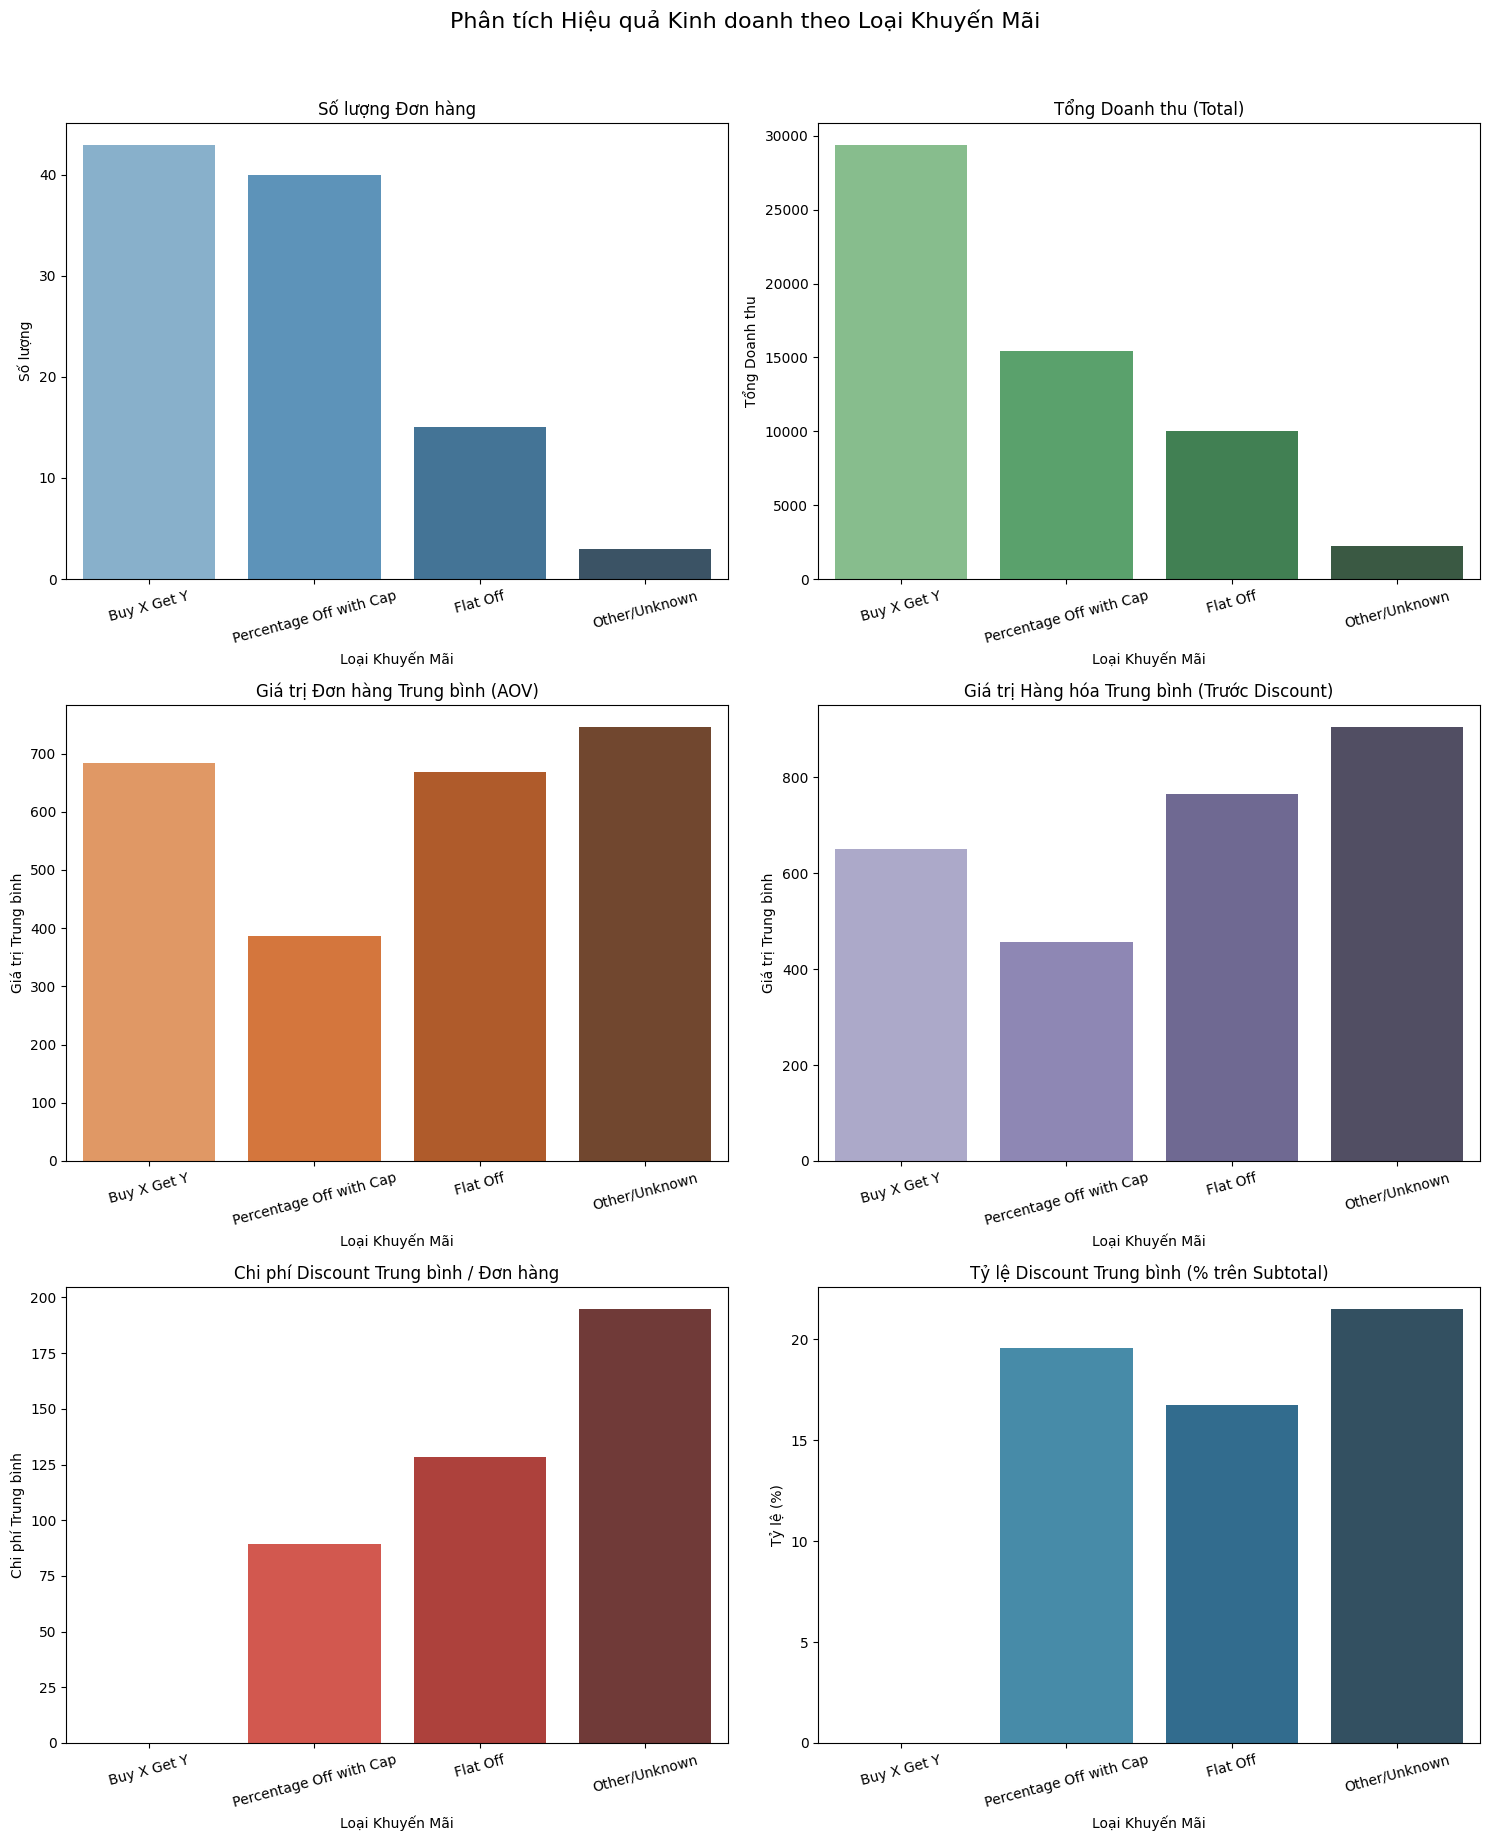

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Giả sử 'df' là DataFrame đã được tải và tiền xử lý (đã có cột 'Discount Category')
# Ví dụ (Bạn đã làm điều này ở phần trước):
# df['Discount construct'] = df['Discount construct'].fillna('No Discount')
# def clean_discount(text):
#     if isinstance(text, str):
#         if '%' in text and 'off upto' in text: return 'Percentage Off with Cap'
#         elif 'Flat' in text and 'off' in text: return 'Flat Off'
#         elif text == 'No Discount': return 'No Discount'
#         elif 'Buy' in text and 'Get' in text: return 'Buy X Get Y'
#     return 'Other/Unknown'
# df['Discount Category'] = df['Discount construct'].apply(clean_discount)

# --- Bước 1: Tổng hợp dữ liệu theo Discount Category ---
print("--- Bước 1: Tổng hợp dữ liệu theo Loại Khuyến Mãi ---")

# Tính tổng chi phí giảm giá số cho mỗi đơn hàng trước khi tổng hợp
discount_cols_numeric = [
    'Restaurant discount (Promo)',
    'Restaurant discount (Flat offs, Freebies & others)',
    'Gold discount',
    'Brand pack discount'
]
df['Total Numerical Discount Cost'] = df[discount_cols_numeric].sum(axis=1)

# Thực hiện tổng hợp
agg_metrics = {
    'Order ID': ('Order ID', 'count'),           # Đếm số lượng đơn hàng
    'Total': ('Total', 'sum'),                  # Tổng doanh thu sau giảm giá
    'Bill subtotal': ('Bill subtotal', 'sum'),  # Tổng giá trị hàng hóa trước giảm giá
    'Total Numerical Discount Cost': ('Total Numerical Discount Cost', 'sum'), # Tổng chi phí giảm giá số
    'Packaging charges': ('Packaging charges', 'sum') # Tổng phí đóng gói
}

agg_df = df.groupby('Discount Category').agg(**agg_metrics).reset_index()

# Đổi tên cột cho rõ ràng hơn
agg_df.rename(columns={
    'Order ID': 'Số lượng đơn hàng',
    'Total': 'Tổng Doanh thu (Total)',
    'Bill subtotal': 'Tổng Giá trị hàng hóa (Subtotal)',
    'Total Numerical Discount Cost': 'Tổng Chi phí Discount',
    'Packaging charges': 'Tổng Phí Đóng gói'
}, inplace=True)

# Tính toán các chỉ số trung bình và tỷ lệ
agg_df['AOV (Average Total)'] = agg_df['Tổng Doanh thu (Total)'] / agg_df['Số lượng đơn hàng']
agg_df['Average Bill Subtotal'] = agg_df['Tổng Giá trị hàng hóa (Subtotal)'] / agg_df['Số lượng đơn hàng']
agg_df['Average Discount per Order'] = agg_df['Tổng Chi phí Discount'] / agg_df['Số lượng đơn hàng']
# Tránh chia cho 0 nếu Tổng Giá trị hàng hóa = 0
agg_df['Average Discount % (of Subtotal)'] = np.where(
    agg_df['Tổng Giá trị hàng hóa (Subtotal)'] > 0,
    (agg_df['Tổng Chi phí Discount'] / agg_df['Tổng Giá trị hàng hóa (Subtotal)']) * 100,
    0
)

# Sắp xếp theo số lượng đơn hàng để dễ so sánh
agg_df = agg_df.sort_values(by='Số lượng đơn hàng', ascending=False)

print("Bảng tổng hợp hiệu quả theo Loại Khuyến Mãi:")
# Định dạng số để dễ đọc hơn
pd.options.display.float_format = '{:,.2f}'.format
print(agg_df)
print("-" * 70)


# --- Bước 2: Trực quan hóa kết quả tổng hợp ---
print("\n--- Bước 2: Trực quan hóa Hiệu quả theo Loại Khuyến Mãi ---")

# Đặt lại định dạng float về mặc định để không ảnh hưởng các plot khác (nếu cần)
# pd.options.display.float_format = None

# Tạo subplot để vẽ nhiều biểu đồ
fig, axes = plt.subplots(3, 2, figsize=(15, 18)) # 3 hàng, 2 cột
fig.suptitle('Phân tích Hiệu quả Kinh doanh theo Loại Khuyến Mãi', fontsize=16, y=1.02)

# 1. Số lượng đơn hàng
sns.barplot(ax=axes[0, 0], x='Discount Category', y='Số lượng đơn hàng', data=agg_df, palette='Blues_d')
axes[0, 0].set_title('Số lượng Đơn hàng')
axes[0, 0].set_xlabel('Loại Khuyến Mãi')
axes[0, 0].set_ylabel('Số lượng')
axes[0, 0].tick_params(axis='x', rotation=15)

# 2. Tổng Doanh thu (Total)
sns.barplot(ax=axes[0, 1], x='Discount Category', y='Tổng Doanh thu (Total)', data=agg_df, palette='Greens_d')
axes[0, 1].set_title('Tổng Doanh thu (Total)')
axes[0, 1].set_xlabel('Loại Khuyến Mãi')
axes[0, 1].set_ylabel('Tổng Doanh thu')
axes[0, 1].tick_params(axis='x', rotation=15)

# 3. AOV (Average Total)
sns.barplot(ax=axes[1, 0], x='Discount Category', y='AOV (Average Total)', data=agg_df, palette='Oranges_d')
axes[1, 0].set_title('Giá trị Đơn hàng Trung bình (AOV)')
axes[1, 0].set_xlabel('Loại Khuyến Mãi')
axes[1, 0].set_ylabel('Giá trị Trung bình')
axes[1, 0].tick_params(axis='x', rotation=15)

# 4. Average Bill Subtotal
sns.barplot(ax=axes[1, 1], x='Discount Category', y='Average Bill Subtotal', data=agg_df, palette='Purples_d')
axes[1, 1].set_title('Giá trị Hàng hóa Trung bình (Trước Discount)')
axes[1, 1].set_xlabel('Loại Khuyến Mãi')
axes[1, 1].set_ylabel('Giá trị Trung bình')
axes[1, 1].tick_params(axis='x', rotation=15)

# 5. Average Discount per Order
sns.barplot(ax=axes[2, 0], x='Discount Category', y='Average Discount per Order', data=agg_df, palette='Reds_d')
axes[2, 0].set_title('Chi phí Discount Trung bình / Đơn hàng')
axes[2, 0].set_xlabel('Loại Khuyến Mãi')
axes[2, 0].set_ylabel('Chi phí Trung bình')
axes[2, 0].tick_params(axis='x', rotation=15)

# 6. Average Discount % (of Subtotal)
sns.barplot(ax=axes[2, 1], x='Discount Category', y='Average Discount % (of Subtotal)', data=agg_df, palette='YlGnBu_d')
axes[2, 1].set_title('Tỷ lệ Discount Trung bình (% trên Subtotal)')
axes[2, 1].set_xlabel('Loại Khuyến Mãi')
axes[2, 1].set_ylabel('Tỷ lệ (%)')
axes[2, 1].tick_params(axis='x', rotation=15)

# Điều chỉnh layout và hiển thị
plt.tight_layout()
plt.show()

# 8: ANOVA cho AOV vừa phân tích ở trên


--- 3.1: Phân tích ANOVA trên Giá trị Đơn hàng Trung bình (AOV) ---

Xem xét lại ANOVA trên 'Total' (Phần 4):
P-value cho sự khác biệt về 'Total' giữa các nhóm: 0.0001
-> Có sự khác biệt đáng kể về mặt thống kê trong giá trị Total TRUNG BÌNH giữa các nhóm khuyến mãi.
   Điều này có thể gợi ý rằng AOV (Average Total) cũng khác nhau, nhưng cần kiểm định thêm nếu muốn chắc chắn chỉ về AOV.
----------------------------------------------------------------------

--- 3.2: Phân tích Phân bổ Đơn hàng theo Giờ trong Ngày ---


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3344\2278627772.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value_total = anova_table_total['PR(>F)'][0]


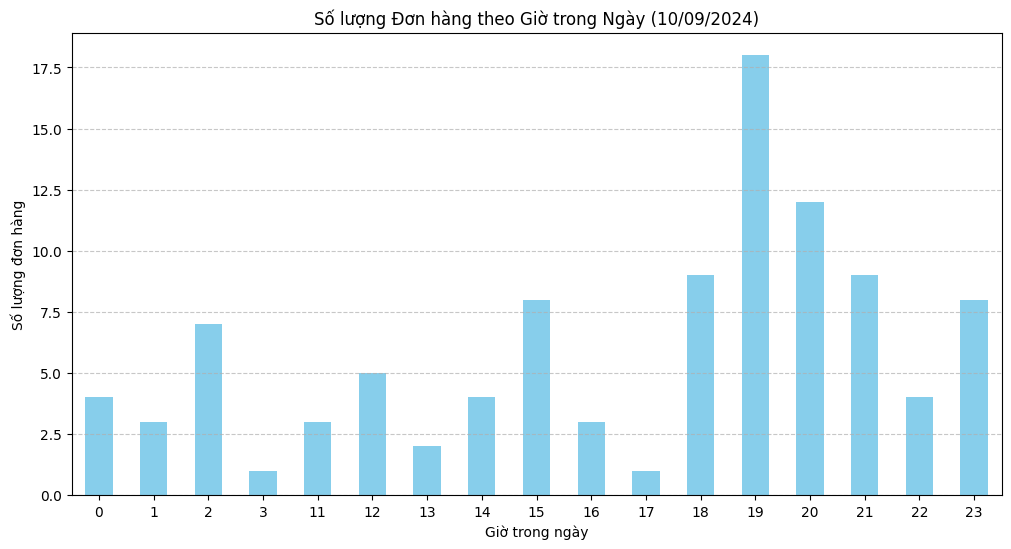


Phân bổ đơn hàng theo Giờ và Loại Khuyến Mãi:
Discount Category  Buy X Get Y  Flat Off  Other/Unknown  \
Hour                                                      
0                            0         2              0   
1                            0         0              0   
2                            0         2              1   
3                            0         0              0   
11                           2         0              0   
12                           3         0              0   
13                           2         0              0   
14                           3         0              0   
15                           2         0              0   
16                           2         1              0   
17                           1         0              0   
18                           6         0              0   
19                          13         0              2   
20                           5         3              0   
21       

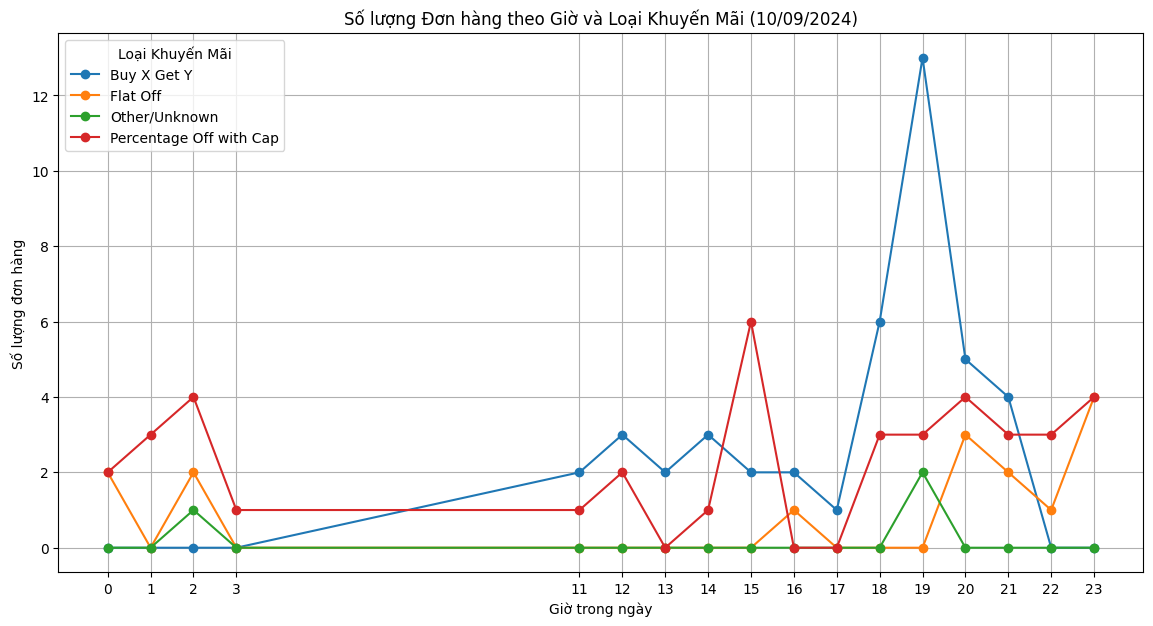

----------------------------------------------------------------------

--- 3.3: Phân tích Khách hàng Cơ bản ---

Số lượng Khách hàng Khác nhau theo Loại Khuyến Mãi:
Discount Category
Buy X Get Y                43
Percentage Off with Cap    38
Flat Off                   14
Other/Unknown               3
Name: Customer ID, dtype: int64


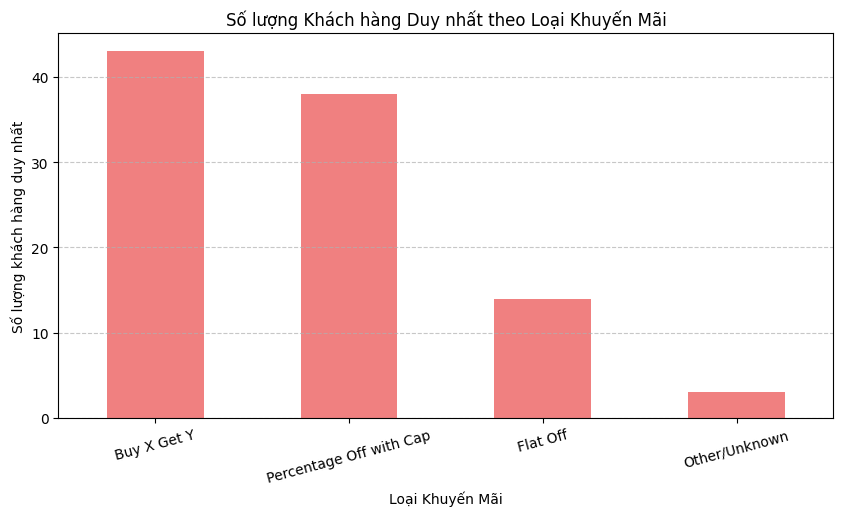


Phân phối Tần suất Đặt hàng của Khách hàng:
count   96.00
mean     1.05
std      0.22
min      1.00
25%      1.00
50%      1.00
75%      1.00
max      2.00
Name: count, dtype: float64


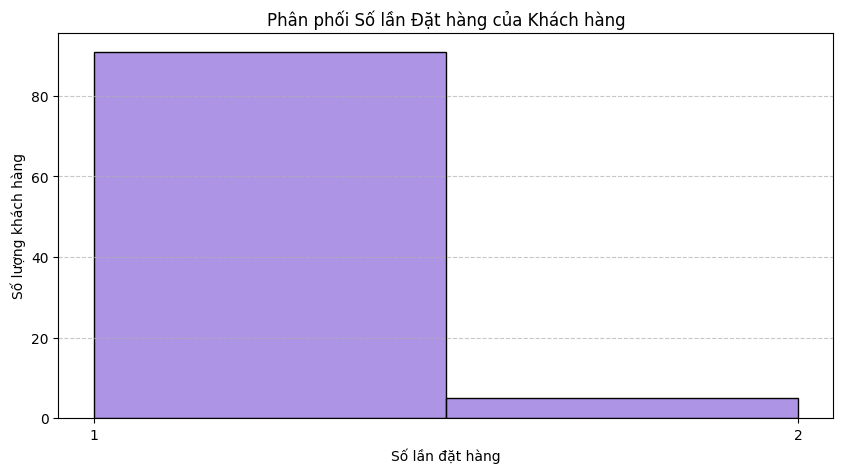


Trong tập dữ liệu này, có 96 khách hàng khác nhau.
Khách hàng đặt nhiều đơn nhất đã đặt: 2 đơn.
Số khách hàng chỉ đặt 1 đơn: 91.


In [18]:
from statsmodels.formula.api import ols
import statsmodels.api as sm
import matplotlib.dates as mdates

# --- 3.1: ANOVA trên Giá trị Đơn hàng Trung bình (AOV) ---
print("\n--- 3.1: Phân tích ANOVA trên Giá trị Đơn hàng Trung bình (AOV) ---")
# Sử dụng bảng agg_df từ Bước 1

# Cần ít nhất 2 nhóm có đủ dữ liệu để so sánh AOV
# (Dữ liệu agg_df thường có ít dòng hơn df gốc)
if agg_df.shape[0] >= 2 and agg_df['Số lượng đơn hàng'].min() >= 2: # Kiểm tra có ít nhất 2 nhóm và mỗi nhóm > 1 đơn
    # Chúng ta cần dữ liệu gốc để chạy ANOVA đúng cách trên AOV theo category
    # Tạo lại mô hình ANOVA trên cột 'Total' của df gốc, NHƯNG diễn giải kết quả
    # với trọng tâm là liệu AOV có khác biệt hay không.
    # ANOVA gốc đã thực hiện ở phần 4, ta xem lại p-value của nó
    print("\nXem xét lại ANOVA trên 'Total' (Phần 4):")
    try:
        # Chạy lại hoặc lấy kết quả từ phần 4 nếu có
        model_anova_total = ols('Total ~ C(Q("Discount Category"))', data=df_anova).fit()
        anova_table_total = sm.stats.anova_lm(model_anova_total, typ=2)
        p_value_total = anova_table_total['PR(>F)'][0]
        print(f"P-value cho sự khác biệt về 'Total' giữa các nhóm: {p_value_total:.4f}")
        if p_value_total < 0.05:
             print("-> Có sự khác biệt đáng kể về mặt thống kê trong giá trị Total TRUNG BÌNH giữa các nhóm khuyến mãi.")
             print("   Điều này có thể gợi ý rằng AOV (Average Total) cũng khác nhau, nhưng cần kiểm định thêm nếu muốn chắc chắn chỉ về AOV.")
        else:
             print("-> Không có đủ bằng chứng cho thấy giá trị Total TRUNG BÌNH khác biệt đáng kể giữa các nhóm khuyến mãi.")

        # (Nâng cao hơn: Có thể dùng pairwise t-test hoặc Tukey HSD sau ANOVA để xem nhóm nào khác nhóm nào)
        # from statsmodels.stats.multicomp import pairwise_tukeyhsd
        # tukey = pairwise_tukeyhsd(endog=df_anova['Total'], groups=df_anova['Discount Category'], alpha=0.05)
        # print("\nKiểm định Tukey HSD (So sánh từng cặp nhóm):")
        # print(tukey)

    except Exception as e:
        print(f"Lỗi khi thực hiện lại ANOVA trên Total: {e}")

else:
    print("Không đủ nhóm hoặc dữ liệu trong các nhóm tổng hợp để thực hiện ANOVA đáng tin cậy trên AOV.")

print("-" * 70)

# --- 3.2: Phân tích Đơn hàng theo Giờ trong Ngày ---
print("\n--- 3.2: Phân tích Phân bổ Đơn hàng theo Giờ trong Ngày ---")
# Chuyển đổi sang datetime nếu chưa làm
df['Order Placed At'] = pd.to_datetime(df['Order Placed At'])
# Trích xuất giờ
df['Hour'] = df['Order Placed At'].dt.hour

orders_by_hour = df.groupby('Hour')['Order ID'].count()

plt.figure(figsize=(12, 6))
orders_by_hour.plot(kind='bar', color='skyblue')
plt.title('Số lượng Đơn hàng theo Giờ trong Ngày (10/09/2024)')
plt.xlabel('Giờ trong ngày')
plt.ylabel('Số lượng đơn hàng')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Phân tích theo giờ và loại discount
orders_by_hour_discount = df.groupby(['Hour', 'Discount Category'])['Order ID'].count().unstack(fill_value=0)

if not orders_by_hour_discount.empty:
    print("\nPhân bổ đơn hàng theo Giờ và Loại Khuyến Mãi:")
    print(orders_by_hour_discount)
    orders_by_hour_discount.plot(kind='line', figsize=(14, 7), marker='o', linestyle='-')
    plt.title('Số lượng Đơn hàng theo Giờ và Loại Khuyến Mãi (10/09/2024)')
    plt.xlabel('Giờ trong ngày')
    plt.ylabel('Số lượng đơn hàng')
    plt.xticks(orders_by_hour_discount.index) # Đảm bảo hiển thị đủ các giờ có dữ liệu
    plt.legend(title='Loại Khuyến Mãi')
    plt.grid(True)
    plt.show()
else:
    print("\nKhông có đủ dữ liệu để phân tích theo giờ và loại khuyến mãi.")


print("-" * 70)

# --- 3.3: Phân tích Khách hàng cơ bản ---
print("\n--- 3.3: Phân tích Khách hàng Cơ bản ---")

# Số lượng khách hàng khác nhau sử dụng từng loại khuyến mãi
customers_per_discount = df.groupby('Discount Category')['Customer ID'].nunique().sort_values(ascending=False)
print("\nSố lượng Khách hàng Khác nhau theo Loại Khuyến Mãi:")
print(customers_per_discount)

plt.figure(figsize=(10, 5))
customers_per_discount.plot(kind='bar', color='lightcoral')
plt.title('Số lượng Khách hàng Duy nhất theo Loại Khuyến Mãi')
plt.xlabel('Loại Khuyến Mãi')
plt.ylabel('Số lượng khách hàng duy nhất')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Phân tích tần suất đặt hàng của khách hàng
customer_frequency = df['Customer ID'].value_counts()
print("\nPhân phối Tần suất Đặt hàng của Khách hàng:")
print(customer_frequency.describe()) # Xem thống kê mô tả tần suất

plt.figure(figsize=(10, 5))
sns.histplot(customer_frequency, bins=max(1, customer_frequency.max()), kde=False, color='mediumpurple') # Số bins = số lần đặt hàng tối đa
plt.title('Phân phối Số lần Đặt hàng của Khách hàng')
plt.xlabel('Số lần đặt hàng')
plt.ylabel('Số lượng khách hàng')
plt.xticks(range(1, customer_frequency.max() + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"\nTrong tập dữ liệu này, có {df['Customer ID'].nunique()} khách hàng khác nhau.")
print(f"Khách hàng đặt nhiều đơn nhất đã đặt: {customer_frequency.max()} đơn.")
print(f"Số khách hàng chỉ đặt 1 đơn: {sum(customer_frequency == 1)}.")

# 9: Dự đoán What-if

## 9.1. Giảm mức Percentage Off
- Giả sử giảm mức giảm giá từ "40% off upto Rs.80" xuống "30% off upto Rs.60"
=> Ước tính chi phí discount mới cho nhóm này
=> Tính Tổng total ước tính mới


--- 1. Mô phỏng 'What-if': Thay đổi Percentage Off ---

Kịch bản: Giảm thành '30% off upto Rs.60' cho nhóm 'Percentage Off'
  - Số lượng đơn hàng giả định không đổi: 40
  - Average Bill Subtotal (giữ nguyên): 456.68
  - Average Discount / Đơn (Mới): 60.00
  - Tổng Chi phí Discount Thực tế: 3,571.62
  - Tổng Chi phí Discount Ước tính Mới: 2,400.00
  - Tổng Doanh thu (Total) Thực tế: 15,430.15
  - Tổng Doanh thu (Total) Ước tính Mới: 16,601.77
  - Thay đổi Doanh thu ước tính: 1,171.62
  - Thay đổi Chi phí Discount ước tính: -1,171.62

--- Trực quan hóa So sánh Kịch bản ---


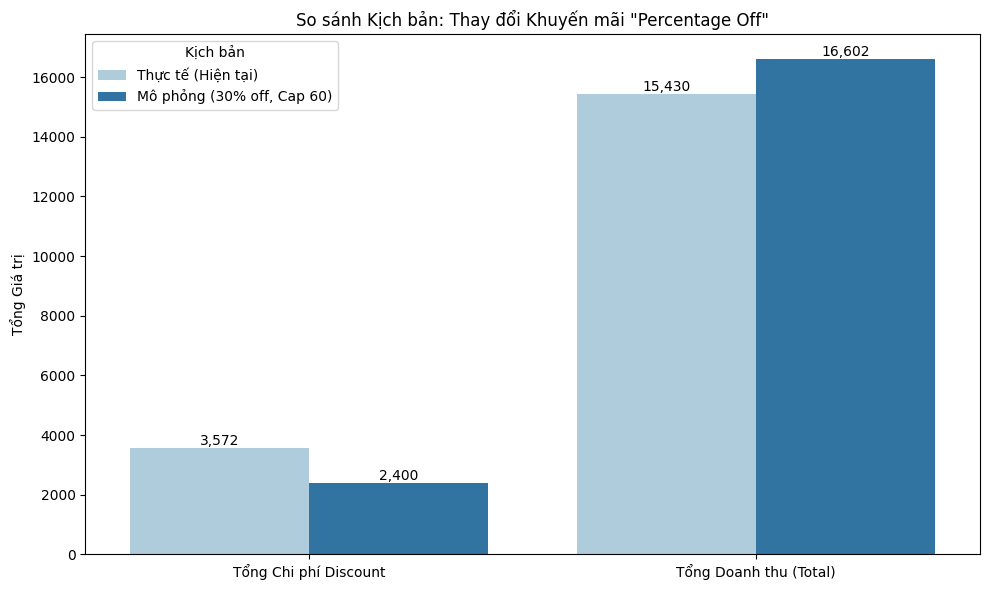

----------------------------------------------------------------------


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- 1. Mô phỏng "What-if": Giảm mức Percentage Off ---
print("\n--- 1. Mô phỏng 'What-if': Thay đổi Percentage Off ---")

# Lấy dữ liệu của nhóm 'Percentage Off with Cap' từ bảng agg_df
try:
    percent_off_data = agg_df[agg_df['Discount Category'] == 'Percentage Off with Cap'].iloc[0]

    # Dữ liệu thực tế
    total_discount_cost_actual = percent_off_data['Tổng Chi phí Discount']
    total_revenue_actual = percent_off_data['Tổng Doanh thu (Total)']
    avg_subtotal_percent_off = percent_off_data['Average Bill Subtotal']
    total_orders_percent_off = percent_off_data['Số lượng đơn hàng']
    total_subtotal_percent_off = percent_off_data['Tổng Giá trị hàng hóa (Subtotal)']
    total_packaging_percent_off = percent_off_data['Tổng Phí Đóng gói']

    # --- Tính toán Kịch bản mới ---
    # Kịch bản mới: 30% off upto Rs.60
    new_discount_percent = 0.30
    new_discount_cap = 60.0

    avg_discount_new = min(avg_subtotal_percent_off * new_discount_percent, new_discount_cap)
    total_discount_cost_new = avg_discount_new * total_orders_percent_off
    total_revenue_new = total_subtotal_percent_off - total_discount_cost_new + total_packaging_percent_off

    # --- In kết quả tính toán (như trước) ---
    print(f"\nKịch bản: Giảm thành '30% off upto Rs.60' cho nhóm 'Percentage Off'")
    print(f"  - Số lượng đơn hàng giả định không đổi: {total_orders_percent_off:,.0f}")
    print(f"  - Average Bill Subtotal (giữ nguyên): {avg_subtotal_percent_off:,.2f}")
    print(f"  - Average Discount / Đơn (Mới): {avg_discount_new:,.2f}")
    print(f"  - Tổng Chi phí Discount Thực tế: {total_discount_cost_actual:,.2f}")
    print(f"  - Tổng Chi phí Discount Ước tính Mới: {total_discount_cost_new:,.2f}")
    print(f"  - Tổng Doanh thu (Total) Thực tế: {total_revenue_actual:,.2f}")
    print(f"  - Tổng Doanh thu (Total) Ước tính Mới: {total_revenue_new:,.2f}")
    print(f"  - Thay đổi Doanh thu ước tính: {total_revenue_new - total_revenue_actual:,.2f}")
    print(f"  - Thay đổi Chi phí Discount ước tính: {total_discount_cost_new - total_discount_cost_actual:,.2f}")


    # --- Trực quan hóa So sánh ---
    print("\n--- Trực quan hóa So sánh Kịch bản ---")

    # Chuẩn bị dữ liệu cho biểu đồ
    plot_data = pd.DataFrame({
        'Chỉ số': ['Tổng Chi phí Discount', 'Tổng Doanh thu (Total)', 'Tổng Chi phí Discount', 'Tổng Doanh thu (Total)'],
        'Kịch bản': ['Thực tế (Hiện tại)', 'Thực tế (Hiện tại)', 'Mô phỏng (30% off, Cap 60)', 'Mô phỏng (30% off, Cap 60)'],
        'Giá trị': [total_discount_cost_actual, total_revenue_actual, total_discount_cost_new, total_revenue_new]
    })

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='Chỉ số', y='Giá trị', hue='Kịch bản', data=plot_data, palette='Paired')

    # Thêm giá trị lên trên các cột
    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.0f}') # Định dạng số nguyên

    plt.title('So sánh Kịch bản: Thay đổi Khuyến mãi "Percentage Off"')
    plt.ylabel('Tổng Giá trị')
    plt.xlabel('') # Có thể bỏ trống hoặc ghi 'Chỉ số so sánh'
    plt.xticks(rotation=0)
    plt.legend(title='Kịch bản')
    plt.tight_layout()
    plt.show()

except IndexError:
    print("Không tìm thấy nhóm 'Percentage Off with Cap' trong dữ liệu tổng hợp để mô phỏng.")
except KeyError as e:
     print(f"Thiếu cột cần thiết trong agg_df để mô phỏng: {e}")


print("-" * 70)

## 9.2. Dự đoán AOV dựa trên Loại Khuyến mãi
- Dự đoán xem nếu chỉ biết loại khuyến mãi sắp tới được áp dụng, thì giá trị đơn hàng trung bình (AOV) dự kiến sẽ là bao nhiêu
- Nếu áp dụng khuyến mãi 'Buy X Get Y', AOV dự kiến sẽ là [giá trị AOV của nhóm 'Buy X Get Y' trong quá khứ]



--- 2. Phân bổ Total và AOV Dự kiến theo Loại Khuyến mãi ---
AOV Dự kiến cho từng Loại Khuyến Mãi (dựa trên dữ liệu quá khứ):
                         AOV Dự kiến
Buy X Get Y                   683.97
Percentage Off with Cap       385.75
Flat Off                      669.06
Other/Unknown                 746.24


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3344\3047858683.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Discount Category', y='Total', data=df, palette='viridis', showfliers=True) # showfliers=True để hiện các điểm ngoại lệ


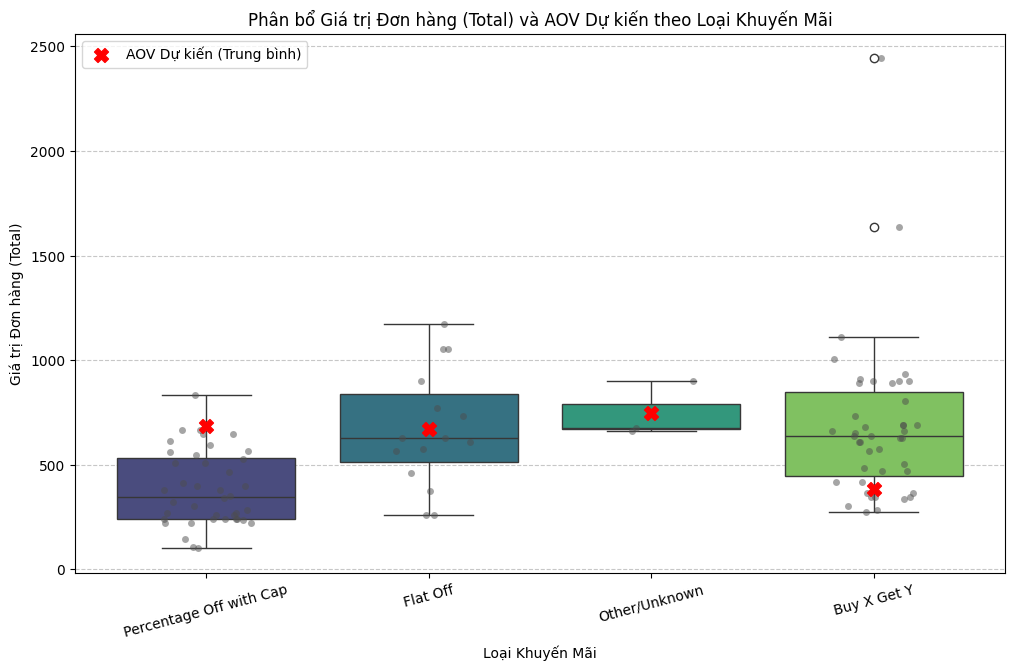


Giải thích biểu đồ:
- Biểu đồ này thể hiện sự phân bổ của giá trị 'Total' cho các đơn hàng thuộc từng loại khuyến mãi.
- Mỗi 'hộp' (boxplot) cho thấy khoảng tứ phân vị (IQR - 50% dữ liệu ở giữa), đường kẻ ngang giữa hộp là trung vị (median).
- Các điểm đen nhỏ (stripplot) là các giá trị 'Total' thực tế của từng đơn hàng.
- Điểm 'X' màu đỏ đánh dấu giá trị trung bình (AOV) của mỗi nhóm - đây là 'AOV dự kiến' đơn giản nhất nếu bạn áp dụng loại khuyến mãi đó.
- Bạn có thể thấy mức độ tập trung/phân tán của các đơn hàng quanh AOV dự kiến và liệu có các đơn hàng ngoại lệ (giá trị rất cao/thấp) hay không.
- Ví dụ: Nếu một hộp rất hẹp và các điểm tập trung gần dấu X đỏ, thì AOV dự kiến đó khá đáng tin cậy cho nhóm đó. Nếu hộp rộng hoặc có nhiều điểm xa dấu X, AOV trung bình có thể bị ảnh hưởng bởi các giá trị cực đoan.


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- 2. Trực quan hóa Phân bổ Total và AOV Dự kiến theo Loại Khuyến mãi ---
print("\n--- 2. Phân bổ Total và AOV Dự kiến theo Loại Khuyến mãi ---")

# Sử dụng DataFrame gốc 'df' đã có cột 'Discount Category'
# và bảng tổng hợp 'agg_df' để lấy AOV dự kiến

# Lấy AOV dự kiến từ bảng tổng hợp để tham chiếu
aov_predictions_dict = agg_df.set_index('Discount Category')['AOV (Average Total)'].to_dict()
print("AOV Dự kiến cho từng Loại Khuyến Mãi (dựa trên dữ liệu quá khứ):")
print(pd.Series(aov_predictions_dict).to_frame(name='AOV Dự kiến'))


# Trực quan hóa phân bổ và giá trị trung bình
plt.figure(figsize=(12, 7))

# Boxplot để thấy phân vị và ngoại lệ
sns.boxplot(x='Discount Category', y='Total', data=df, palette='viridis', showfliers=True) # showfliers=True để hiện các điểm ngoại lệ

# Stripplot để thấy các điểm dữ liệu thực tế (đặc biệt hữu ích cho nhóm nhỏ)
sns.stripplot(x='Discount Category', y='Total', data=df, color=".3", alpha=0.5, jitter=0.2) # jitter để điểm không chồng lên nhau quá nhiều

# Đánh dấu AOV dự kiến (giá trị trung bình)
# Lấy vị trí x (0, 1, 2, ...) và giá trị AOV tương ứng
categories = sorted(df['Discount Category'].unique()) # Sắp xếp để đảm bảo thứ tự khớp với plot
aov_values = [aov_predictions_dict.get(cat, np.nan) for cat in categories] # Lấy AOV theo đúng thứ tự
plt.scatter(range(len(categories)), aov_values, marker='X', color='red', s=100, zorder=5, label='AOV Dự kiến (Trung bình)') # zorder để điểm nằm trên


plt.title('Phân bổ Giá trị Đơn hàng (Total) và AOV Dự kiến theo Loại Khuyến Mãi')
plt.xlabel('Loại Khuyến Mãi')
plt.ylabel('Giá trị Đơn hàng (Total)')
plt.xticks(rotation=15)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\nGiải thích biểu đồ:")
print("- Biểu đồ này thể hiện sự phân bổ của giá trị 'Total' cho các đơn hàng thuộc từng loại khuyến mãi.")
print("- Mỗi 'hộp' (boxplot) cho thấy khoảng tứ phân vị (IQR - 50% dữ liệu ở giữa), đường kẻ ngang giữa hộp là trung vị (median).")
print("- Các điểm đen nhỏ (stripplot) là các giá trị 'Total' thực tế của từng đơn hàng.")
print("- Điểm 'X' màu đỏ đánh dấu giá trị trung bình (AOV) của mỗi nhóm - đây là 'AOV dự kiến' đơn giản nhất nếu bạn áp dụng loại khuyến mãi đó.")
print("- Bạn có thể thấy mức độ tập trung/phân tán của các đơn hàng quanh AOV dự kiến và liệu có các đơn hàng ngoại lệ (giá trị rất cao/thấp) hay không.")
print("- Ví dụ: Nếu một hộp rất hẹp và các điểm tập trung gần dấu X đỏ, thì AOV dự kiến đó khá đáng tin cậy cho nhóm đó. Nếu hộp rộng hoặc có nhiều điểm xa dấu X, AOV trung bình có thể bị ảnh hưởng bởi các giá trị cực đoan.")

## 9.3. Dự đoán tổng total ngày kế tiếp

### Bước 1: Chuẩn bị dữ liệu Chuỗi thời gian


--- Chuẩn bị Dữ liệu Chuỗi Thời gian ---

Bảng tổng hợp dữ liệu hàng ngày:
            Daily_Orders  Daily_Total_Revenue  Daily_Avg_Bill_Subtotal  \
Order Date                                                               
2024-09-05            11             6,077.40                   674.45   
2024-09-06            63            38,704.45                   617.78   
2024-09-07             7             3,049.20                   514.14   
2024-09-08            10             4,258.91                   485.61   
2024-09-09             3               995.40                   396.00   
2024-09-10             7             4,029.90                   641.86   

            Daily_Avg_Total_Discount  Daily_AOV  
Order Date                                       
2024-09-05                    148.27     552.49  
2024-09-06                     32.68     614.36  
2024-09-07                     99.29     435.60  
2024-09-08                     80.00     425.89  
2024-09-09                     

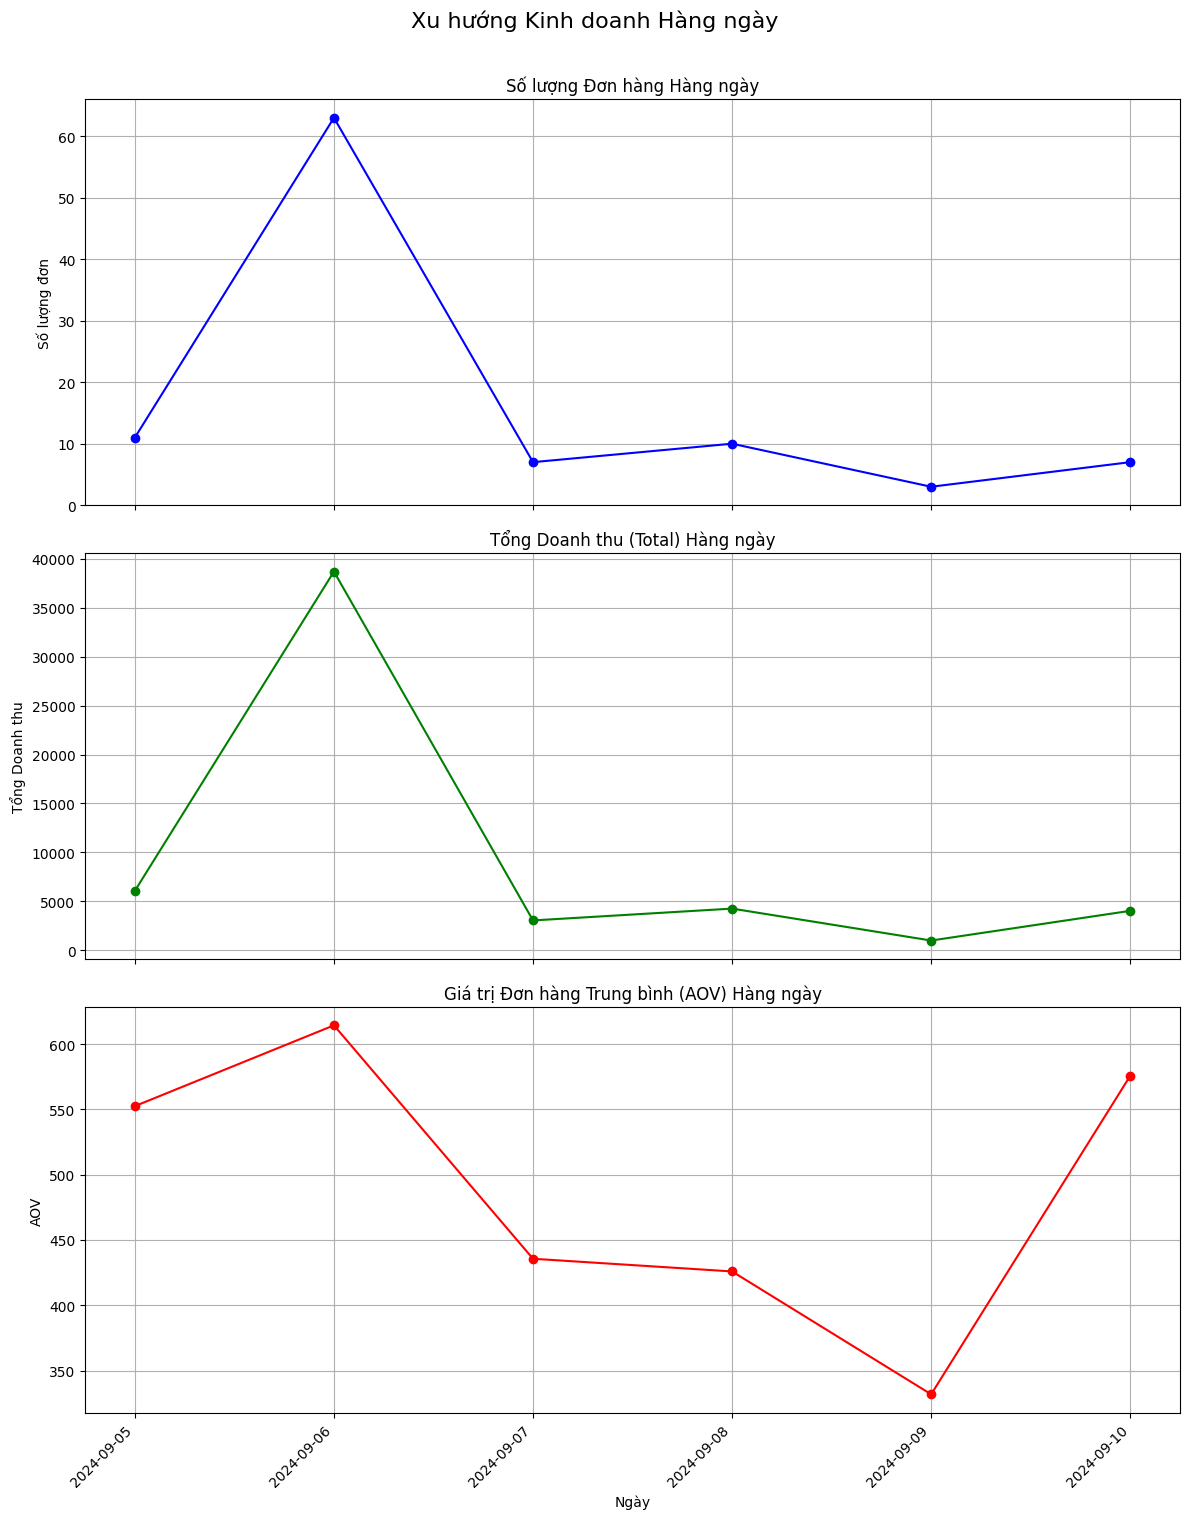


Giải thích biểu đồ chuỗi thời gian:
- Các biểu đồ này cho thấy sự biến động của số lượng đơn hàng, tổng doanh thu và AOV qua các ngày trong tập dữ liệu của bạn.
- Bạn có thể quan sát xem có ngày nào có số lượng đơn/doanh thu đột biến hay không (ví dụ: cuối tuần so với ngày thường?).
- Với khoảng thời gian ngắn (5-6 ngày), việc xác định xu hướng dài hạn hoặc tính thời vụ rõ ràng là rất khó.


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# --- Đảm bảo DataFrame 'df' đã được tải và có cột 'Order Placed At' đúng định dạng ---
# (Tải lại df nếu cần)
# try:
#     df = pd.read_csv('your_updated_data.csv') # Thay bằng tên file đúng
# except UnicodeDecodeError:
#     try:
#         df = pd.read_csv('your_updated_data.csv', encoding='latin1')
#     except Exception as e:
#         print(f"Lỗi khi đọc file CSV: {e}")
#         # exit() # Thoát nếu không đọc được file

# df.columns = df.columns.str.strip()

# --- Chuẩn bị Dữ liệu Thời gian ---
print("\n--- Chuẩn bị Dữ liệu Chuỗi Thời gian ---")

# Chuyển đổi sang datetime và xử lý lỗi nếu có
# df['Order Placed At'] = pd.to_datetime(df['Order Placed At'], errors='coerce')
# Loại bỏ các dòng có ngày giờ không hợp lệ (nếu có)
df.dropna(subset=['Order Placed At'], inplace=True)

# Trích xuất Ngày
df['Order Date'] = df['Order Placed At'].dt.date
df['Order Date'] = pd.to_datetime(df['Order Date']) # Chuyển lại thành datetime để dễ xử lý

# --- Tổng hợp dữ liệu theo Ngày ---
daily_summary = df.groupby('Order Date').agg(
    Daily_Orders=('Order ID', 'count'),
    Daily_Total_Revenue=('Total', 'sum'),
    Daily_Avg_Bill_Subtotal=('Bill subtotal', 'mean'),
    Daily_Avg_Total_Discount=('Total Numerical Discount Cost', 'mean') # Giả sử cột này đã được tạo
).reset_index()

# Tính AOV hàng ngày
daily_summary['Daily_AOV'] = daily_summary['Daily_Total_Revenue'] / daily_summary['Daily_Orders']

# Đặt Ngày làm chỉ mục để dễ dàng phân tích chuỗi thời gian
daily_summary.set_index('Order Date', inplace=True)

# Sắp xếp theo ngày
daily_summary.sort_index(inplace=True)

print("\nBảng tổng hợp dữ liệu hàng ngày:")
print(daily_summary)
print("-" * 70)

# --- Trực quan hóa dữ liệu chuỗi thời gian ---
print("\n--- Trực quan hóa Dữ liệu Chuỗi Thời gian Hàng ngày ---")

fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True) # 3 hàng, 1 cột, chia sẻ trục X
fig.suptitle('Xu hướng Kinh doanh Hàng ngày', fontsize=16, y=1.01)

# 1. Số lượng đơn hàng hàng ngày
axes[0].plot(daily_summary.index, daily_summary['Daily_Orders'], marker='o', linestyle='-', color='b')
axes[0].set_title('Số lượng Đơn hàng Hàng ngày')
axes[0].set_ylabel('Số lượng đơn')
axes[0].grid(True)

# 2. Tổng doanh thu hàng ngày
axes[1].plot(daily_summary.index, daily_summary['Daily_Total_Revenue'], marker='o', linestyle='-', color='g')
axes[1].set_title('Tổng Doanh thu (Total) Hàng ngày')
axes[1].set_ylabel('Tổng Doanh thu')
axes[1].grid(True)

# 3. AOV hàng ngày
axes[2].plot(daily_summary.index, daily_summary['Daily_AOV'], marker='o', linestyle='-', color='r')
axes[2].set_title('Giá trị Đơn hàng Trung bình (AOV) Hàng ngày')
axes[2].set_ylabel('AOV')
axes[2].set_xlabel('Ngày')
axes[2].grid(True)

# Định dạng trục X để hiển thị ngày rõ ràng hơn
for ax in axes:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1)) # Hiển thị mỗi ngày
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\nGiải thích biểu đồ chuỗi thời gian:")
print("- Các biểu đồ này cho thấy sự biến động của số lượng đơn hàng, tổng doanh thu và AOV qua các ngày trong tập dữ liệu của bạn.")
print("- Bạn có thể quan sát xem có ngày nào có số lượng đơn/doanh thu đột biến hay không (ví dụ: cuối tuần so với ngày thường?).")
print("- Với khoảng thời gian ngắn (5-6 ngày), việc xác định xu hướng dài hạn hoặc tính thời vụ rõ ràng là rất khó.")

### Bước 2: Áp dụng Mô hình Dự báo Đơn giản (Ví dụ: Moving Average)


--- Dự báo cho Ngày Tiếp theo bằng Trung bình Trượt (SMA) ---

Dự báo cho ngày: 2024-09-11 (dựa trên SMA 2 ngày)
  - Số lượng đơn hàng dự kiến: 5.0
  - Tổng Doanh thu (Total) dự kiến: 2,512.65


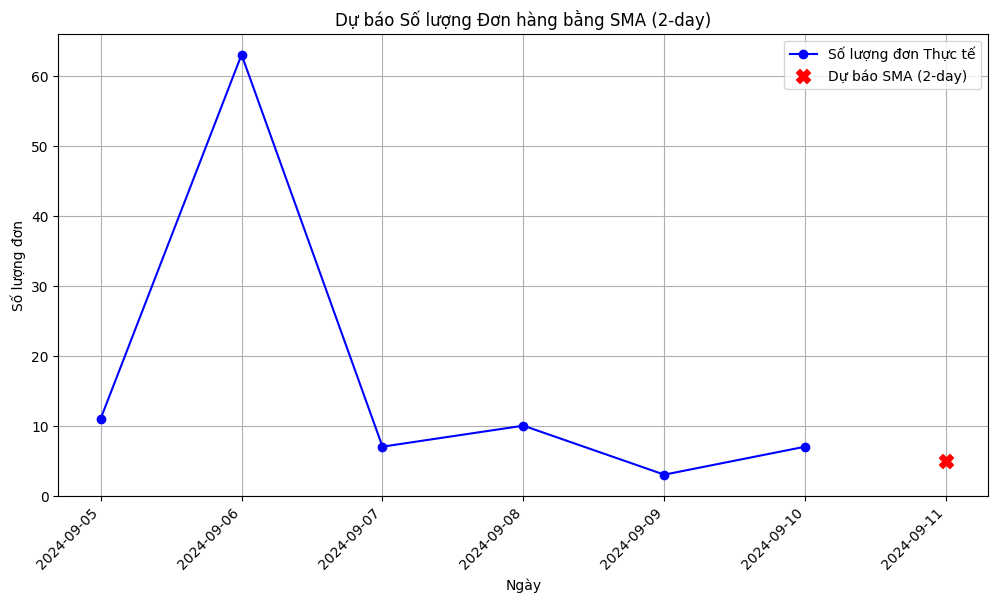

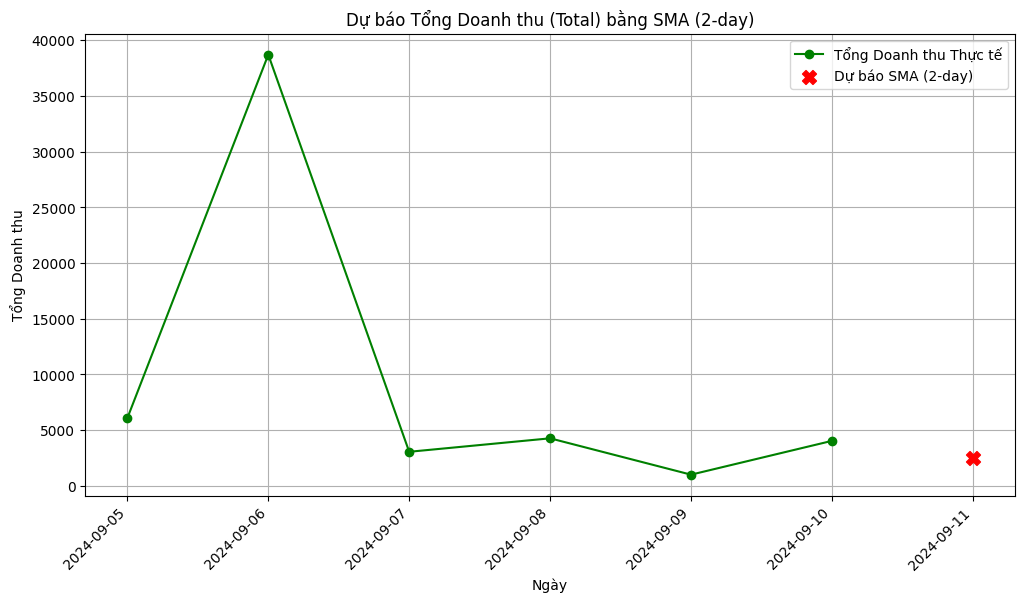

----------------------------------------------------------------------
LƯU Ý QUAN TRỌNG:
- Đây là dự báo rất cơ bản và độ tin cậy thấp do khoảng thời gian dữ liệu ngắn.
- Mô hình này không tính đến các yếu tố như ngày trong tuần, sự kiện đặc biệt, hay tác động cụ thể của từng loại khuyến mãi đang chạy vào ngày đó.
- Để dự báo chính xác hơn, cần dữ liệu dài hơn và các mô hình phức tạp hơn (ARIMA, Prophet, mô hình học máy có tính thời gian).


In [22]:
# --- Bước 2: Dự báo bằng Trung bình trượt Đơn giản (SMA) ---
print("\n--- Dự báo cho Ngày Tiếp theo bằng Trung bình Trượt (SMA) ---")

window_size = 2 # Chọn cửa sổ là 2 ngày gần nhất (có thể thay đổi thành 3 nếu muốn)

if len(daily_summary) >= window_size:
    # Dự báo Số lượng đơn hàng
    last_k_days_orders = daily_summary['Daily_Orders'].iloc[-window_size:]
    predicted_orders_sma = last_k_days_orders.mean()

    # Dự báo Tổng doanh thu
    last_k_days_revenue = daily_summary['Daily_Total_Revenue'].iloc[-window_size:]
    predicted_revenue_sma = last_k_days_revenue.mean()

    # Ngày dự báo
    last_date = daily_summary.index[-1]
    forecast_date = last_date + pd.Timedelta(days=1)

    print(f"\nDự báo cho ngày: {forecast_date.strftime('%Y-%m-%d')} (dựa trên SMA {window_size} ngày)")
    print(f"  - Số lượng đơn hàng dự kiến: {predicted_orders_sma:,.1f}")
    print(f"  - Tổng Doanh thu (Total) dự kiến: {predicted_revenue_sma:,.2f}")

    # --- Trực quan hóa Dự báo ---
    plt.figure(figsize=(12, 6))
    plt.plot(daily_summary.index, daily_summary['Daily_Orders'], marker='o', linestyle='-', color='b', label='Số lượng đơn Thực tế')
    # Vẽ điểm dự báo
    plt.scatter([forecast_date], [predicted_orders_sma], color='red', marker='X', s=100, label=f'Dự báo SMA ({window_size}-day)', zorder=5)
    plt.title(f'Dự báo Số lượng Đơn hàng bằng SMA ({window_size}-day)')
    plt.ylabel('Số lượng đơn')
    plt.xlabel('Ngày')
    plt.legend()
    plt.grid(True)
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45, ha='right')
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(daily_summary.index, daily_summary['Daily_Total_Revenue'], marker='o', linestyle='-', color='g', label='Tổng Doanh thu Thực tế')
    # Vẽ điểm dự báo
    plt.scatter([forecast_date], [predicted_revenue_sma], color='red', marker='X', s=100, label=f'Dự báo SMA ({window_size}-day)', zorder=5)
    plt.title(f'Dự báo Tổng Doanh thu (Total) bằng SMA ({window_size}-day)')
    plt.ylabel('Tổng Doanh thu')
    plt.xlabel('Ngày')
    plt.legend()
    plt.grid(True)
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45, ha='right')
    plt.show()

else:
    print(f"Không đủ dữ liệu (cần ít nhất {window_size} ngày) để thực hiện dự báo SMA.")

print("-" * 70)
print("LƯU Ý QUAN TRỌNG:")
print("- Đây là dự báo rất cơ bản và độ tin cậy thấp do khoảng thời gian dữ liệu ngắn.")
print("- Mô hình này không tính đến các yếu tố như ngày trong tuần, sự kiện đặc biệt, hay tác động cụ thể của từng loại khuyến mãi đang chạy vào ngày đó.")
print("- Để dự báo chính xác hơn, cần dữ liệu dài hơn và các mô hình phức tạp hơn (ARIMA, Prophet, mô hình học máy có tính thời gian).")

## 9.4. Mô phỏng Kịch bản Hỗn hợp Khuyến mãi (khum hiểu)

### Bước 1: Tính toán Số liệu Trung bình Hàng ngày cho Mỗi Loại Khuyến mãi
Chúng ta cần biết trung bình mỗi ngày, mỗi loại khuyến mãi tạo ra bao nhiêu đơn hàng, doanh thu, v.v.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Tính toán số ngày có dữ liệu ---
num_days_in_data = (df['Order Date'].max() - df['Order Date'].min()).days + 1
print(f"Số ngày có dữ liệu trong tập mẫu: {num_days_in_data}")

# --- Tính toán Số liệu Trung bình Hàng ngày ---
# Sử dụng bảng agg_df đã tạo ở Bước 1 của phần trước

# Chia các giá trị tổng cho số ngày để có giá trị trung bình hàng ngày
# Lưu ý: Giả định rằng mỗi loại KM chạy trong suốt thời gian có dữ liệu
# Điều này có thể không hoàn toàn chính xác nếu một KM chỉ chạy 1-2 ngày
agg_df['Avg Daily Orders'] = agg_df['Số lượng đơn hàng'] / num_days_in_data
agg_df['Avg Daily Revenue'] = agg_df['Tổng Doanh thu (Total)'] / num_days_in_data
agg_df['Avg Daily Subtotal'] = agg_df['Tổng Giá trị hàng hóa (Subtotal)'] / num_days_in_data
agg_df['Avg Daily Discount Cost'] = agg_df['Tổng Chi phí Discount'] / num_days_in_data
agg_df['Avg Daily Packaging Cost'] = agg_df['Tổng Phí Đóng gói'] / num_days_in_data


print("\nBảng tổng hợp với số liệu trung bình hàng ngày (ước tính):")
print(agg_df[['Discount Category', 'Avg Daily Orders', 'Avg Daily Revenue', 'Avg Daily Subtotal', 'Avg Daily Discount Cost', 'AOV (Average Total)', 'Average Bill Subtotal']])
print("-" * 70)

Số ngày có dữ liệu trong tập mẫu: 6

Bảng tổng hợp với số liệu trung bình hàng ngày (ước tính):
         Discount Category  Avg Daily Orders  Avg Daily Revenue  \
0              Buy X Get Y              7.17           4,901.75   
3  Percentage Off with Cap              6.67           2,571.69   
1                 Flat Off              2.50           1,672.65   
2            Other/Unknown              0.50             373.12   

   Avg Daily Subtotal  Avg Daily Discount Cost  AOV (Average Total)  \
0            4,668.33                     0.00               683.97   
3            3,044.50                   595.27               385.75   
1            1,913.50                   320.50               669.06   
2              452.85                    97.50               746.24   

   Average Bill Subtotal  
0                 651.40  
3                 456.68  
1                 765.40  
2                 905.70  
----------------------------------------------------------------------


### Bước 2: Định nghĩa và Mô phỏng các Kịch bản
Giả sử chúng ta muốn mô phỏng 2 kịch bản cho 1 tuần (7 ngày) tới:
Kịch bản A: Chỉ chạy "Buy X Get Y" và "Percentage Off with Cap".
Kịch bản B: Chỉ chạy "Flat Off" và "Percentage Off with Cap".


--- Mô phỏng Kịch bản Hỗn hợp Khuyến mãi cho 1 Tuần (7 ngày) ---
*** CẢNH BÁO: Kết quả chỉ là ước tính dựa trên trung bình quá khứ ngắn hạn! ***

Kịch bản A (Ước tính cho 7 ngày): Chỉ chạy Buy X Get Y + Percentage Off
  - Tổng số đơn hàng ước tính: 96.8
  - Tổng doanh thu (Total) ước tính: 52,314.09
  - Tổng chi phí Discount ước tính: 4,166.89
  - AOV (Average Total) ước tính: 540.25

Kịch bản B (Ước tính cho 7 ngày): Chỉ chạy Flat Off + Percentage Off
  - Tổng số đơn hàng ước tính: 64.2
  - Tổng doanh thu (Total) ước tính: 29,710.39
  - Tổng chi phí Discount ước tính: 6,410.39
  - AOV (Average Total) ước tính: 463.02
----------------------------------------------------------------------

--- Trực quan hóa So sánh các Kịch bản Mô phỏng (Ước tính 7 ngày) ---


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3344\571805993.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='Kịch bản', y='Giá trị Ước tính', data=scenario_plot_data[scenario_plot_data['Chỉ số'] == 'Số Đơn hàng'], palette='Accent')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3344\571805993.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='Kịch bản', y='Giá trị Ước tính', data=scenario_plot_data[scenario_plot_data['Chỉ số'] == 'Doanh thu (Total)'], palette='Accent')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3344\571805993.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variab

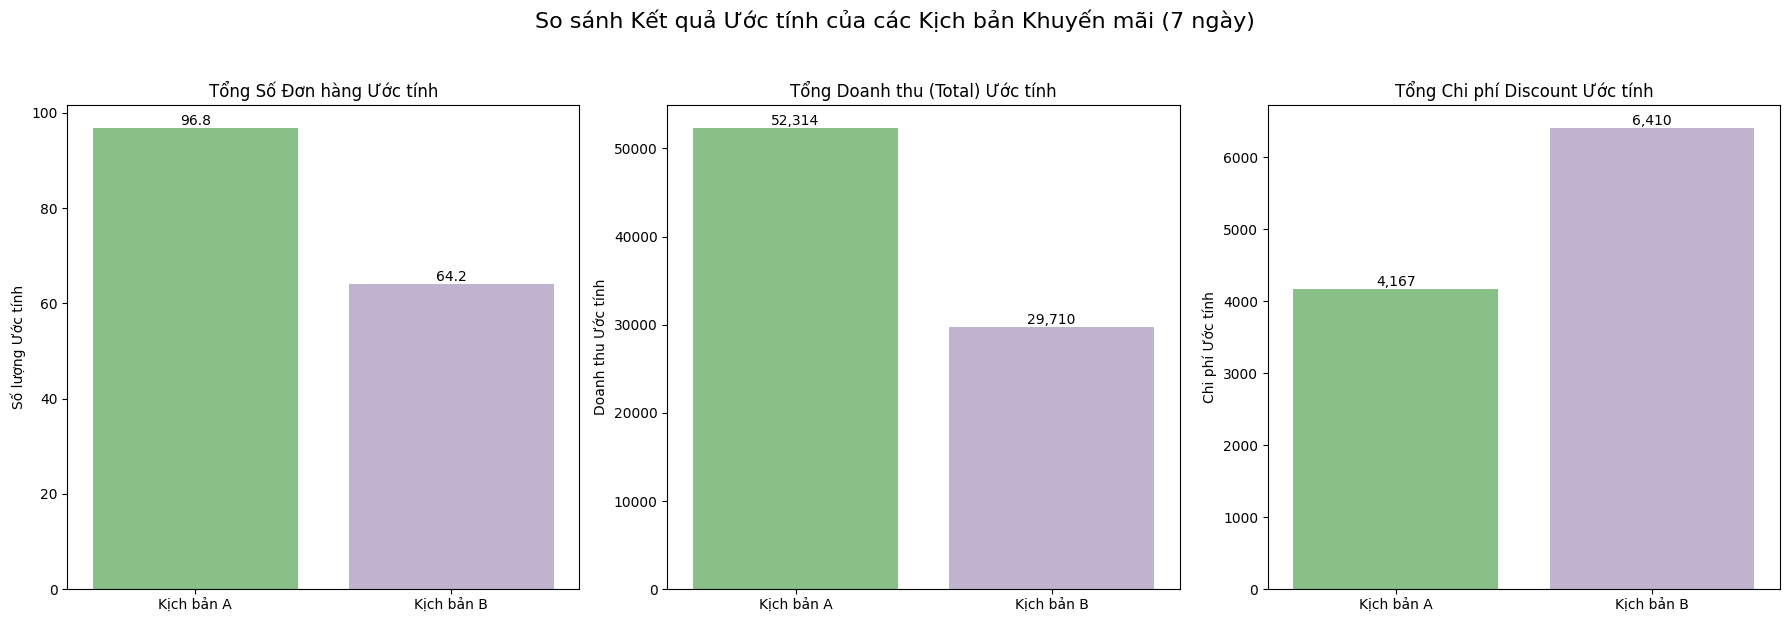

In [24]:
# --- Bước 2: Mô phỏng Kịch bản Hỗn hợp Khuyến mãi ---
print("\n--- Mô phỏng Kịch bản Hỗn hợp Khuyến mãi cho 1 Tuần (7 ngày) ---")
print("*** CẢNH BÁO: Kết quả chỉ là ước tính dựa trên trung bình quá khứ ngắn hạn! ***")

forecast_horizon_days = 7

# --- Kịch bản A: Buy X Get Y + Percentage Off ---
scenario_A_promos = ['Buy X Get Y', 'Percentage Off with Cap']
scenario_A_data = agg_df[agg_df['Discount Category'].isin(scenario_A_promos)]

if not scenario_A_data.empty:
    est_A_orders = scenario_A_data['Avg Daily Orders'].sum() * forecast_horizon_days
    est_A_revenue = scenario_A_data['Avg Daily Revenue'].sum() * forecast_horizon_days
    est_A_discount_cost = scenario_A_data['Avg Daily Discount Cost'].sum() * forecast_horizon_days
    est_A_subtotal = scenario_A_data['Avg Daily Subtotal'].sum() * forecast_horizon_days
    # Ước tính AOV tổng thể cho kịch bản này
    est_A_aov = est_A_revenue / est_A_orders if est_A_orders > 0 else 0

    print("\nKịch bản A (Ước tính cho 7 ngày): Chỉ chạy Buy X Get Y + Percentage Off")
    print(f"  - Tổng số đơn hàng ước tính: {est_A_orders:,.1f}")
    print(f"  - Tổng doanh thu (Total) ước tính: {est_A_revenue:,.2f}")
    print(f"  - Tổng chi phí Discount ước tính: {est_A_discount_cost:,.2f}")
    print(f"  - AOV (Average Total) ước tính: {est_A_aov:,.2f}")
else:
    print("\nKhông đủ dữ liệu cho Kịch bản A.")
    est_A_orders, est_A_revenue, est_A_discount_cost = 0, 0, 0


# --- Kịch bản B: Flat Off + Percentage Off ---
scenario_B_promos = ['Flat Off', 'Percentage Off with Cap']
scenario_B_data = agg_df[agg_df['Discount Category'].isin(scenario_B_promos)]

if not scenario_B_data.empty:
    est_B_orders = scenario_B_data['Avg Daily Orders'].sum() * forecast_horizon_days
    est_B_revenue = scenario_B_data['Avg Daily Revenue'].sum() * forecast_horizon_days
    est_B_discount_cost = scenario_B_data['Avg Daily Discount Cost'].sum() * forecast_horizon_days
    est_B_subtotal = scenario_B_data['Avg Daily Subtotal'].sum() * forecast_horizon_days
    est_B_aov = est_B_revenue / est_B_orders if est_B_orders > 0 else 0

    print("\nKịch bản B (Ước tính cho 7 ngày): Chỉ chạy Flat Off + Percentage Off")
    print(f"  - Tổng số đơn hàng ước tính: {est_B_orders:,.1f}")
    print(f"  - Tổng doanh thu (Total) ước tính: {est_B_revenue:,.2f}")
    print(f"  - Tổng chi phí Discount ước tính: {est_B_discount_cost:,.2f}")
    print(f"  - AOV (Average Total) ước tính: {est_B_aov:,.2f}")
else:
    print("\nKhông đủ dữ liệu cho Kịch bản B.")
    est_B_orders, est_B_revenue, est_B_discount_cost = 0, 0, 0

print("-" * 70)


# --- Trực quan hóa So sánh Kịch bản ---
print("\n--- Trực quan hóa So sánh các Kịch bản Mô phỏng (Ước tính 7 ngày) ---")

scenario_plot_data = pd.DataFrame({
    'Kịch bản': ['Kịch bản A', 'Kịch bản A', 'Kịch bản A', 'Kịch bản B', 'Kịch bản B', 'Kịch bản B'],
    'Chỉ số': ['Số Đơn hàng', 'Doanh thu (Total)', 'Chi phí Discount', 'Số Đơn hàng', 'Doanh thu (Total)', 'Chi phí Discount'],
    'Giá trị Ước tính': [est_A_orders, est_A_revenue, est_A_discount_cost, est_B_orders, est_B_revenue, est_B_discount_cost]
})

fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # 1 hàng, 3 cột
fig.suptitle('So sánh Kết quả Ước tính của các Kịch bản Khuyến mãi (7 ngày)', fontsize=16, y=1.03)

# 1. Số Đơn hàng Ước tính
sns.barplot(ax=axes[0], x='Kịch bản', y='Giá trị Ước tính', data=scenario_plot_data[scenario_plot_data['Chỉ số'] == 'Số Đơn hàng'], palette='Accent')
axes[0].set_title('Tổng Số Đơn hàng Ước tính')
axes[0].set_ylabel('Số lượng Ước tính')
axes[0].set_xlabel('')
for container in axes[0].containers: axes[0].bar_label(container, fmt='{:,.1f}')

# 2. Doanh thu Ước tính
sns.barplot(ax=axes[1], x='Kịch bản', y='Giá trị Ước tính', data=scenario_plot_data[scenario_plot_data['Chỉ số'] == 'Doanh thu (Total)'], palette='Accent')
axes[1].set_title('Tổng Doanh thu (Total) Ước tính')
axes[1].set_ylabel('Doanh thu Ước tính')
axes[1].set_xlabel('')
for container in axes[1].containers: axes[1].bar_label(container, fmt='{:,.0f}')

# 3. Chi phí Discount Ước tính
sns.barplot(ax=axes[2], x='Kịch bản', y='Giá trị Ước tính', data=scenario_plot_data[scenario_plot_data['Chỉ số'] == 'Chi phí Discount'], palette='Accent')
axes[2].set_title('Tổng Chi phí Discount Ước tính')
axes[2].set_ylabel('Chi phí Ước tính')
axes[2].set_xlabel('')
for container in axes[2].containers: axes[2].bar_label(container, fmt='{:,.0f}')


plt.tight_layout()
plt.show()